In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 23

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 26.21 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148398 entries, 0 to 148397
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 488.0+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

#add this info to a settings dict?
stats_current_gameweek = current_gw
picks_current_gameweek = current_gw
# current_season = 20252026

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 39549

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35492    89.74            4057
                        recoveries_elo_p90sq_3      35492    89.74            4057
                               tackles_p90sq_3      35492    89.74            4057
                           tackles_elo_p90sq_3      35492    89.74            4057
                                   cbi_p90sq_3      35492    89.74            4057
                               cbi_elo_p90sq_3      35492    89.74            4057
                        defensive_cont_p90sq_3      35492    89.74            4057
                    defensive_cont_elo_p90sq_3      35492    89.74            4057
                               tackles_p90sq_5      35460    89.66            4089
                           tackles_elo_p90sq_5      35460    89

In [5]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>15)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132215,Bukayo Saka,16.0,11.0,Wolves,0.375133
132217,Bukayo Saka,17.0,3.0,Everton,0.371668
132219,Bukayo Saka,18.0,7.0,Brighton,0.369029
132221,Bukayo Saka,19.0,6.0,Aston Villa,0.369398
132223,Bukayo Saka,20.0,4.0,Bournemouth,0.367637
132225,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132227,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132229,Bukayo Saka,23.0,0.0,Man Utd,0.359322
132231,Bukayo Saka,24.0,NaN,Leeds,0.359322
132233,Bukayo Saka,25.0,NaN,Sunderland,0.359322


In [6]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [7]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [8]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [9]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [10]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2264/7313

Training Set Performance:
R² Score: 0.8429
RMSE: 13.0305
MAE: 10.7469

Test Set Performance:
R² Score: 0.3316
RMSE: 26.7965
MAE: 21.9285

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.202920
          minutes_elo_3    0.100618
   opp_team_elo_p90sq_3    0.036212
  opp_team_elo_p90sq_at    0.021116
      team_elo_p90sq_10    0.016963
   opp_team_elo_p90sq_5    0.012481
  opp_team_elo_p90sq_10    0.011009
      team_elo_p90sq_at    0.010889
opp_team_elo_elo_p90_10    0.010057
           opp_team_elo    0.009546
               team_elo    0.008461
         opp_team_elo_3    0.007969
     total_points_elo_3    0.007933
       team_elo_p90sq_3    0.007901
       team_elo_p90sq_5    0.007154
         opp_team_elo_5    0.006959
           bps_p90sq_at    0.006921
  clean_sheets_p90sq_at    0.006653
               elo_diff    0.006493
        xg_over_g_ratio    0.006173


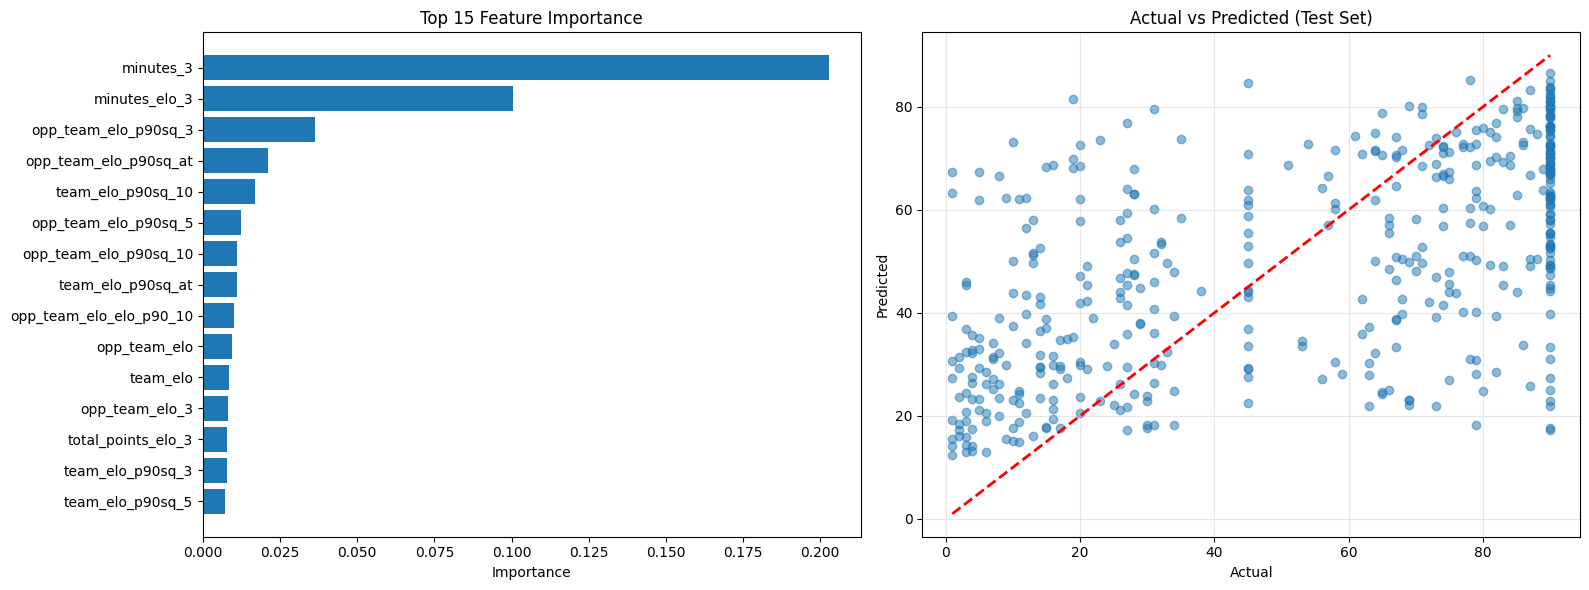

Cleaned df size: 7854/27357

Training Set Performance:
R² Score: 0.6734
RMSE: 18.4456
MAE: 15.2907

Test Set Performance:
R² Score: 0.3228
RMSE: 26.4155
MAE: 21.5036

Top 20 Feature Importances:
              feature  importance
            minutes_3    0.341226
 opp_team_elo_p90sq_3    0.023115
        minutes_elo_3    0.022405
opp_team_elo_p90sq_10    0.020396
               bps_10    0.017993
           minutes_10    0.013333
       minutes_elo_10    0.009964
         opp_team_elo    0.009461
      xg_over_g_ratio    0.008405
    minutes_elo_p90_5    0.008201
clean_sheets_p90sq_at    0.007728
           bps_elo_10    0.007178
       opp_team_elo_3    0.007100
 opp_team_elo_p90sq_5    0.006961
       bonus_p90sq_at    0.006861
     team_elo_p90sq_5    0.006831
      opp_team_elo_10    0.006815
opp_team_elo_p90sq_at    0.006722
                bps_3    0.006351
       opp_team_elo_5    0.006001


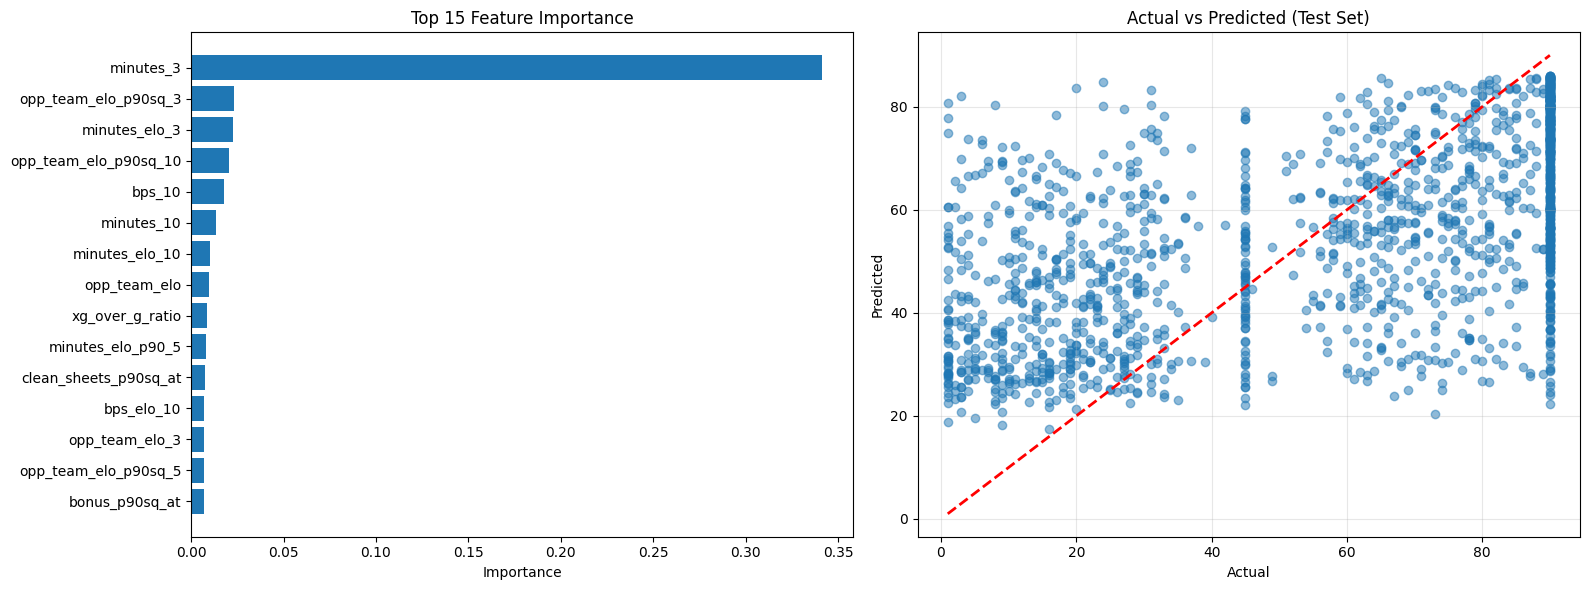

Cleaned df size: 4907/19679

Training Set Performance:
R² Score: 0.6726
RMSE: 17.0404
MAE: 12.7673

Test Set Performance:
R² Score: 0.2236
RMSE: 25.4816
MAE: 19.1307

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.187967
    opp_team_elo_p90sq_3    0.039452
   opp_team_elo_p90sq_10    0.031489
        team_elo_p90sq_3    0.030516
       team_elo_p90sq_10    0.012275
    opp_team_elo_p90sq_5    0.012266
           minutes_elo_3    0.010881
          opp_team_elo_3    0.010236
         xg_over_g_ratio    0.009956
 goals_conceded_p90sq_at    0.009823
         opp_team_elo_10    0.009656
        team_elo_p90sq_5    0.008932
              minutes_10    0.008776
       xassists_p90sq_at    0.008669
            opp_team_elo    0.008552
                elo_diff    0.008489
               bps_elo_3    0.008156
            bps_p90sq_at    0.007743
opp_team_elo_elo_p90sq_3    0.007691
          opp_team_elo_5    0.007403


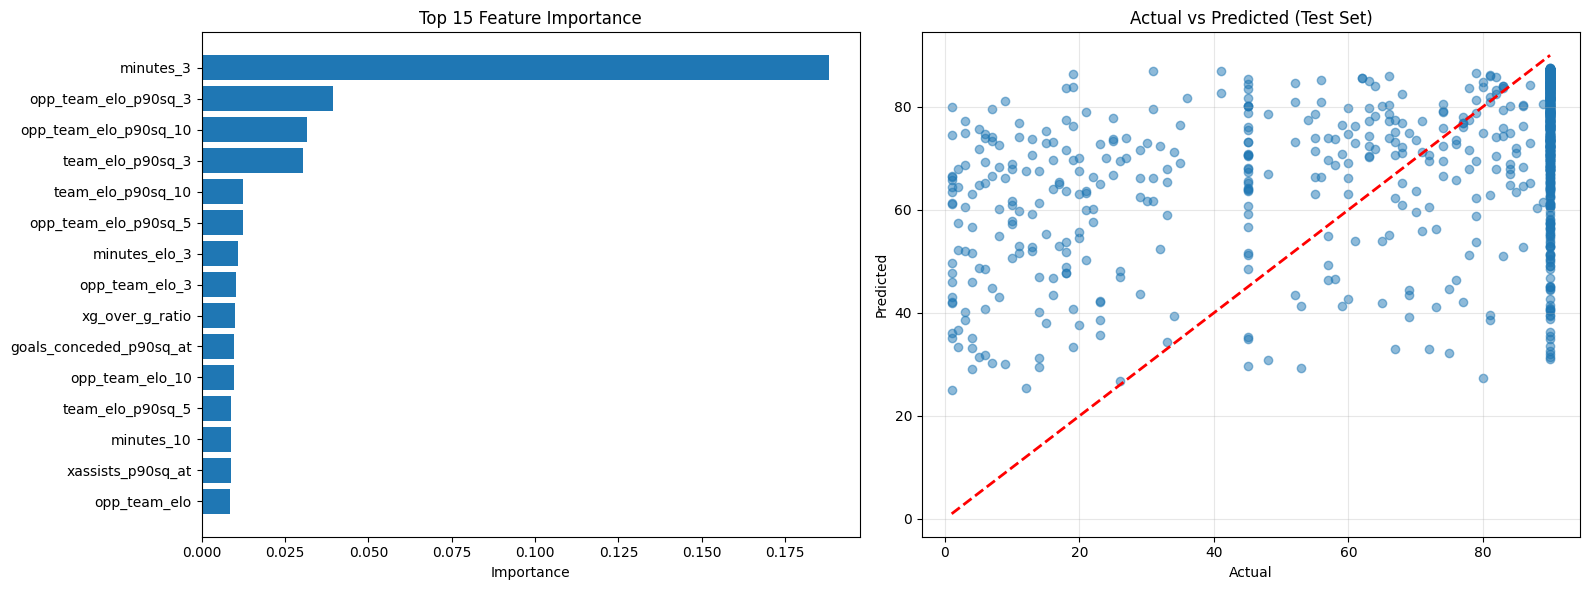

Cleaned df size: 3811/4072

Training Set Performance:
R² Score: 0.7332
RMSE: 2.5474
MAE: 0.5062

Test Set Performance:
R² Score: -0.0625
RMSE: 6.1008
MAE: 1.2832

Top 20 Feature Importances:
                 feature  importance
   opp_team_elo_p90sq_at    0.063929
            bps_p90sq_at    0.039246
            opp_team_elo    0.038264
       saves_elo_p90sq_5    0.031249
             bps_p90sq_5    0.026307
          saves_p90sq_10    0.024073
           minutes_elo_3    0.021874
       saves_elo_p90sq_3    0.020593
          team_elo_elo_3    0.019866
                  bps_10    0.018912
       team_elo_p90sq_at    0.018394
    opp_team_elo_p90sq_5    0.017809
opp_team_elo_elo_p90sq_3    0.017426
             bps_p90sq_3    0.017220
           saves_p90sq_3    0.016766
   opp_team_elo_p90sq_10    0.015832
                   bps_5    0.014869
               bps_p90_5    0.014723
   total_points_p90sq_at    0.014400
         opp_team_elo_10    0.013928


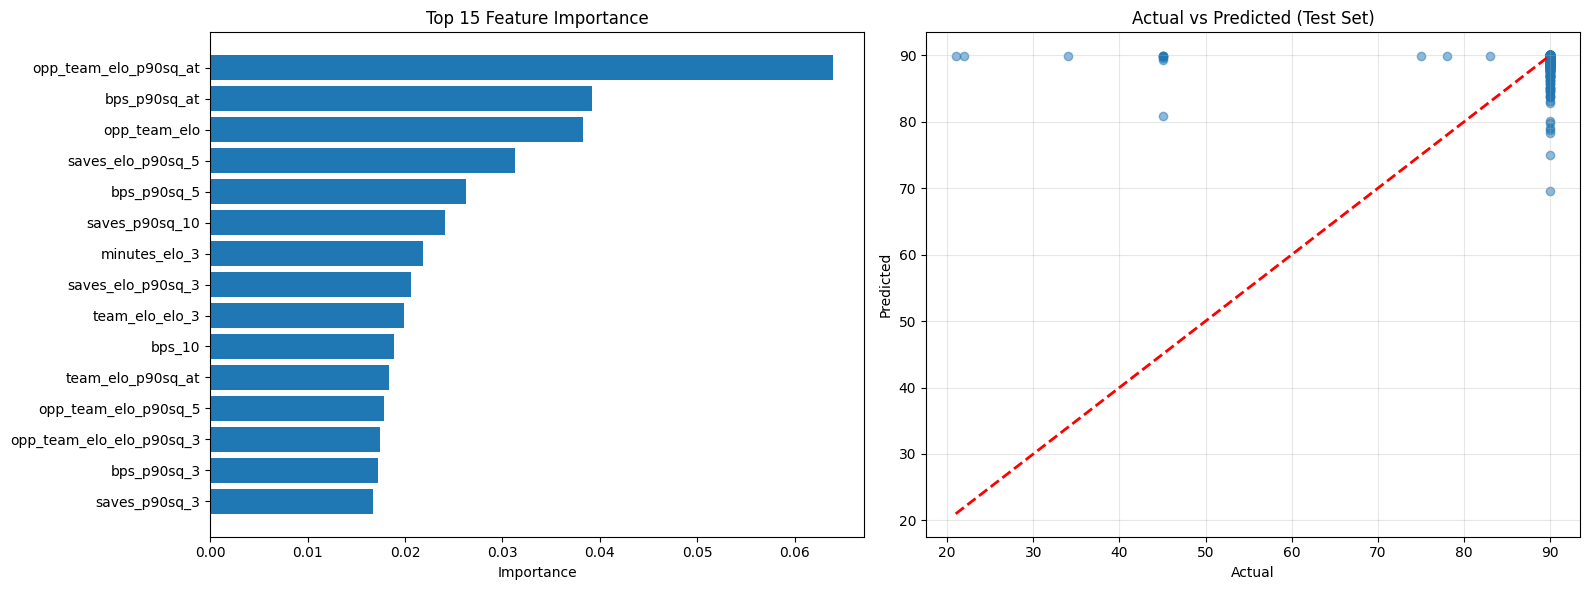

In [11]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2485/4205

Training Set Performance:
R² Score: 0.6180
RMSE: 0.2457
MAE: 0.1951

Test Set Performance:
R² Score: -0.0937
RMSE: 0.3810
MAE: 0.2960

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.055675
    goals_scored_p90sq_at    0.043167
                 team_elo    0.020053
          opp_team_elo_10    0.018667
             opp_team_elo    0.018115
          xg_over_g_ratio    0.018099
           opp_team_elo_5    0.017409
           opp_team_elo_3    0.016404
     opp_team_elo_p90sq_5    0.014651
         team_elo_p90sq_3    0.014374
           bonus_p90sq_at    0.014334
  goals_conceded_p90sq_at    0.013522
     opp_team_elo_p90sq_3    0.012022
      goals_scored_elo_10    0.011467
       minutes_elo_p90_10    0.010635
    clean_sheets_p90sq_at    0.009710
total_points_elo_p90sq_10    0.009646
  opp_team_elo_elo_p90_10    0.009476
              team_elo_10    0.009328
   

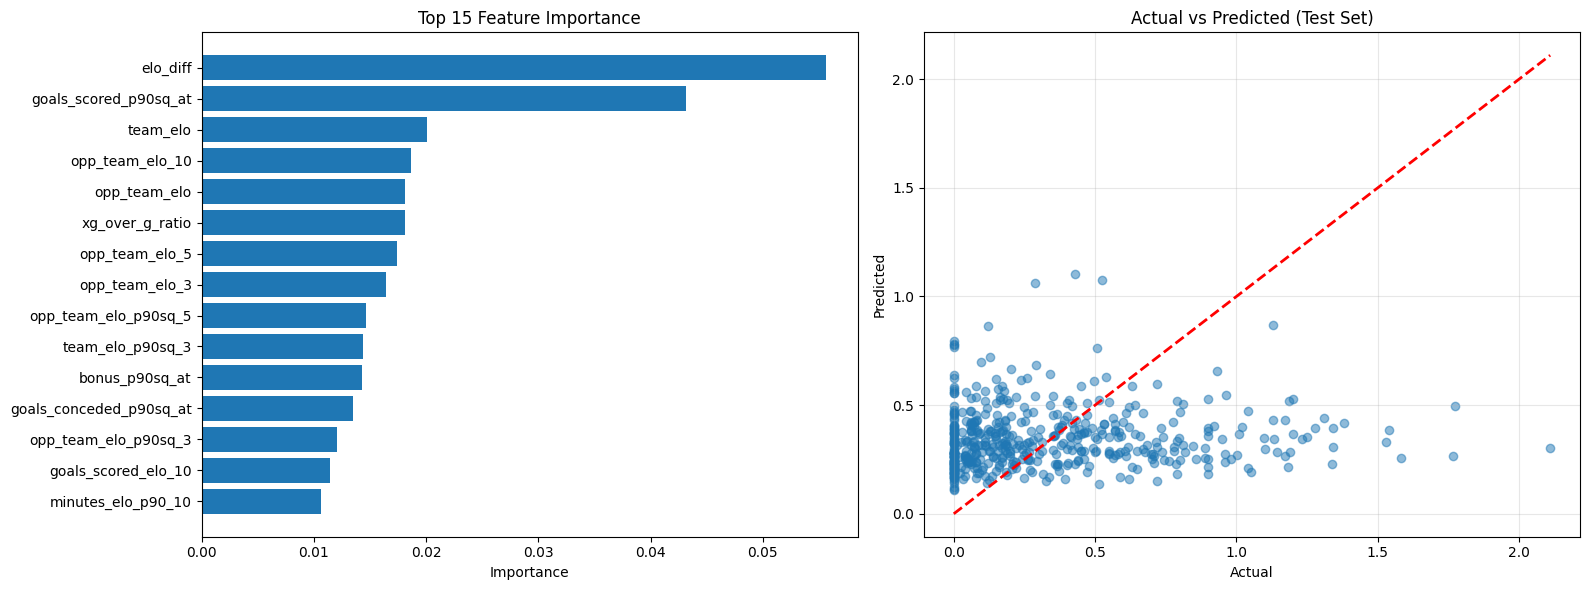

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11586/17994

Training Set Performance:
R² Score: 0.3934
RMSE: 0.1711
MAE: 0.1162

Test Set Performance:
R² Score: 0.0664
RMSE: 0.2219
MAE: 0.1400

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.145949
           opp_team_elo    0.030128
         bonus_p90sq_at    0.025872
               elo_diff    0.019976
    goals_scored_elo_10    0.017093
        opp_team_elo_10    0.016935
           bps_p90sq_at    0.014170
         opp_team_elo_5    0.013017
goals_conceded_p90sq_at    0.012865
           bps_p90sq_10    0.012843
    total_points_elo_10    0.012711
              bps_p90_3    0.011465
      team_elo_p90sq_at    0.011462
         opp_team_elo_3    0.010702
     total_points_p90_3    0.010499
  clean_sheets_p90sq_at    0.010355
             bps_elo_10    0.010185
  opp_team_elo_p90sq_10    0.009985
            bps_p90sq_3    0.009454
        bps_elo_p90sq_5    0.009143


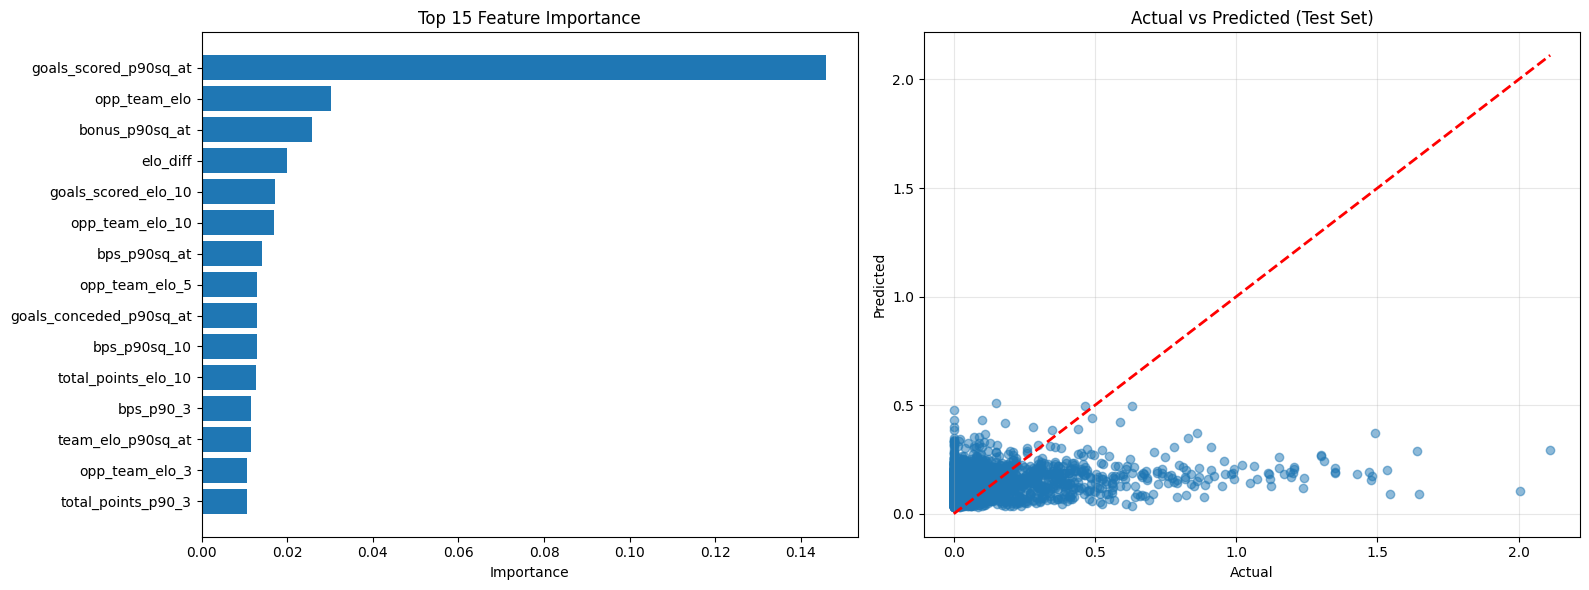

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 9904/16091

Training Set Performance:
R² Score: 0.2439
RMSE: 0.0937
MAE: 0.0554

Test Set Performance:
R² Score: -0.0189
RMSE: 0.0996
MAE: 0.0590

Top 20 Feature Importances:
                    feature  importance
             opp_team_elo_3    0.034289
               opp_team_elo    0.033537
      goals_scored_p90sq_at    0.031553
        goals_scored_elo_10    0.022188
               bps_p90sq_at    0.020542
          team_elo_p90sq_at    0.019704
      opp_team_elo_p90sq_10    0.019012
             opp_team_elo_5    0.018909
                   elo_diff    0.018017
    goals_conceded_p90sq_at    0.017118
      goals_conceded_elo_10    0.016027
     opp_team_elo_elo_p90_3    0.015266
            opp_team_elo_10    0.014474
      total_points_p90sq_at    0.014115
     opp_team_elo_elo_p90_5    0.013540
       opp_team_elo_p90sq_3    0.013415
          minutes_elo_p90_3    0.012752
goals_conceded_elo_p90sq_10    0.012299
  

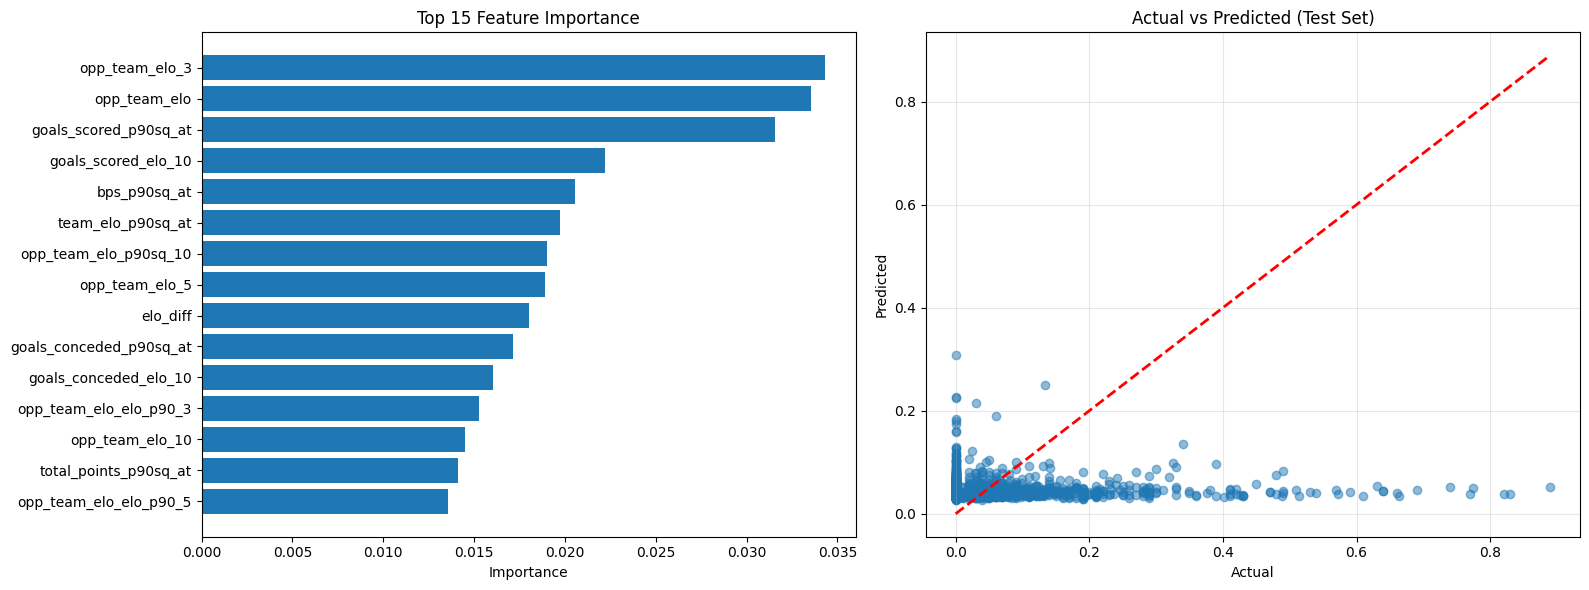

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2673/4483

Training Set Performance:
R² Score: 0.5164
RMSE: 0.0825
MAE: 0.0556

Test Set Performance:
R² Score: 0.0264
RMSE: 0.1253
MAE: 0.0767

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.051670
                elo_diff    0.028689
    goals_conceded_elo_3    0.022027
          opp_team_elo_3    0.021825
       minutes_elo_p90_5    0.021250
       minutes_elo_p90_3    0.017689
    total_points_p90sq_3    0.016535
total_points_elo_p90sq_3    0.015527
             bps_p90sq_3    0.014111
           bps_elo_p90_5    0.013800
           minutes_elo_3    0.013658
            bonus_elo_10    0.013547
       team_elo_p90sq_at    0.012933
          minutes_elo_10    0.012702
              bps_elo_10    0.012553
         xg_over_g_ratio    0.012387
 opp_team_elo_elo_p90_10    0.012270
      total_points_p90_3    0.012172
             bps_p90sq_5    0.012039
         opp_team_elo_

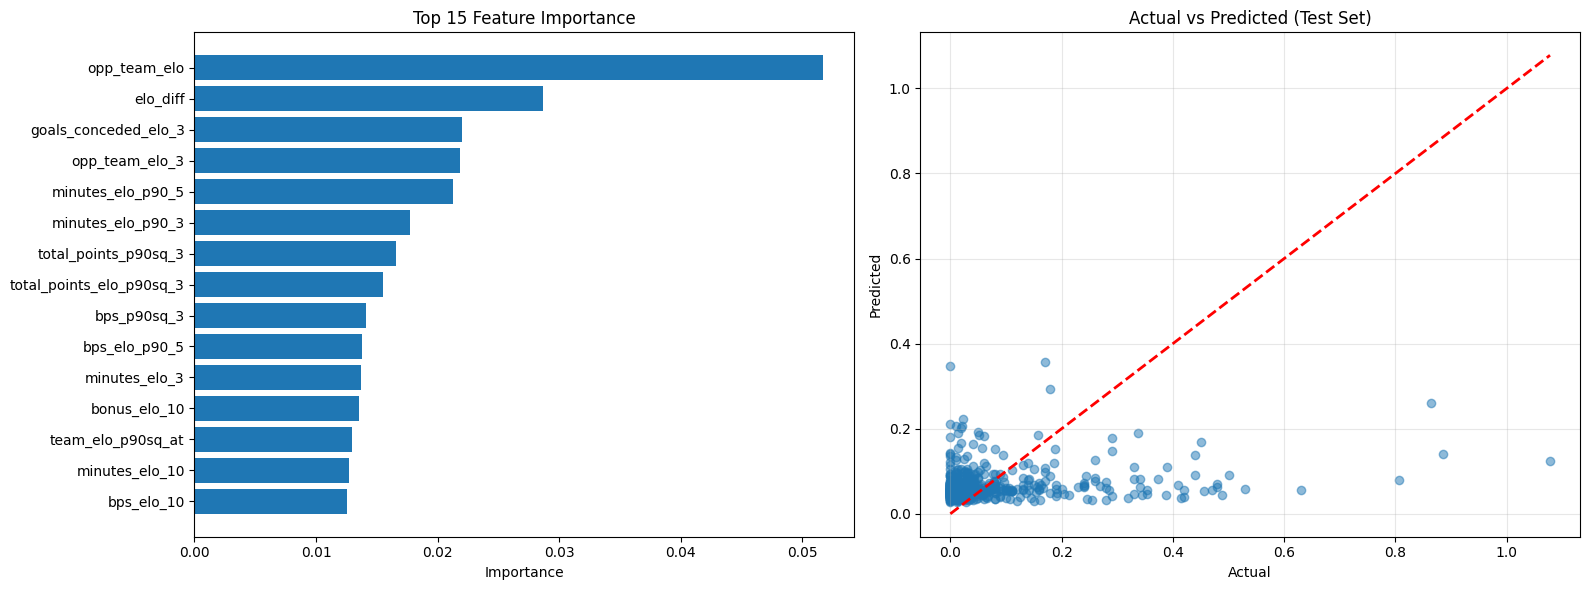

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 11997/18609

Training Set Performance:
R² Score: 0.4137
RMSE: 0.1257
MAE: 0.0892

Test Set Performance:
R² Score: 0.0629
RMSE: 0.1527
MAE: 0.1036

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.112304
            bonus_p90sq_at    0.086607
              opp_team_elo    0.020598
                bps_elo_10    0.019427
       total_points_elo_10    0.018863
            opp_team_elo_5    0.014740
     goals_scored_p90sq_at    0.014673
              bps_p90sq_at    0.013574
                    bps_10    0.013473
           opp_team_elo_10    0.012393
         team_elo_p90sq_at    0.012194
     clean_sheets_p90sq_at    0.011137
            opp_team_elo_3    0.010941
   goals_conceded_p90sq_at    0.010326
              bps_p90sq_10    0.010213
     total_points_p90sq_at    0.009752
               bps_p90sq_5    0.008970
            bps_elo_p90_10    0.008632
          bps_elo_p

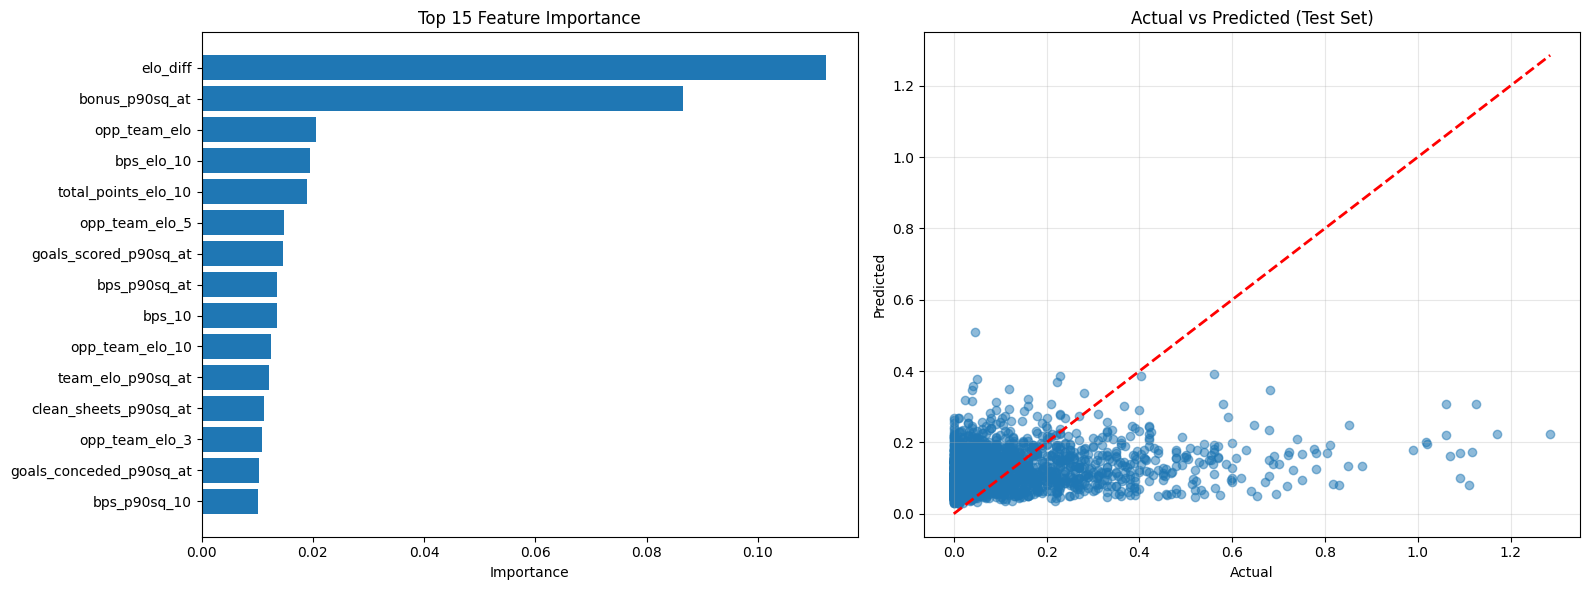

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10096/16407

Training Set Performance:
R² Score: 0.4094
RMSE: 0.0797
MAE: 0.0492

Test Set Performance:
R² Score: 0.0316
RMSE: 0.1041
MAE: 0.0592

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.112563
               elo_diff    0.034948
           opp_team_elo    0.031204
    minutes_elo_p90sq_3    0.024874
        opp_team_elo_10    0.018878
         opp_team_elo_3    0.017120
goals_conceded_p90sq_at    0.016767
                  bps_3    0.015842
  goals_scored_p90sq_at    0.015548
            bps_p90sq_5    0.014692
   goals_conceded_elo_3    0.014402
           bps_p90sq_at    0.014295
  clean_sheets_p90sq_at    0.012963
              bps_p90_5    0.012880
  opp_team_elo_p90sq_at    0.012877
                  bps_5    0.012099
 total_points_elo_p90_3    0.011821
     team_elo_elo_p90_3    0.011397
                 bps_10    0.010910
         minutes_elo_10    0.010542


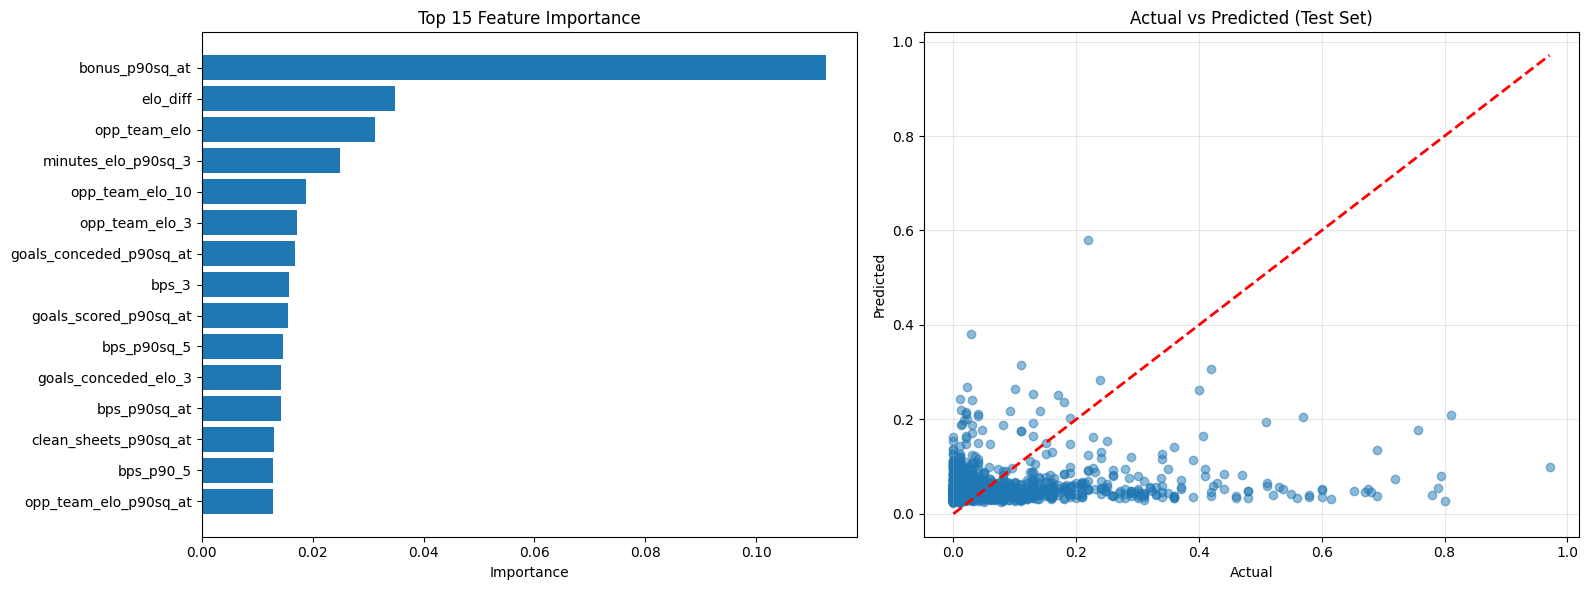

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2673/4483

Training Set Performance:
R² Score: 0.6688
RMSE: 0.5333
MAE: 0.4308

Test Set Performance:
R² Score: 0.1543
RMSE: 0.8842
MAE: 0.6855

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.155201
               opp_team_elo    0.055174
            xg_over_g_ratio    0.040475
      clean_sheets_p90sq_at    0.025326
    goals_conceded_p90sq_at    0.018199
             opp_team_elo_5    0.018161
            opp_team_elo_10    0.018135
             opp_team_elo_3    0.012008
         minutes_elo_p90_10    0.011849
               bps_p90sq_at    0.010367
          team_elo_p90sq_at    0.010353
             bonus_p90sq_at    0.010093
      goals_scored_p90sq_at    0.009848
    goals_conceded_p90sq_10    0.008991
              minutes_elo_3    0.008973
goals_conceded_elo_p90sq_10    0.008352
      opp_team_elo_p90sq_at    0.008187
      total_points_p90sq_at    0.0

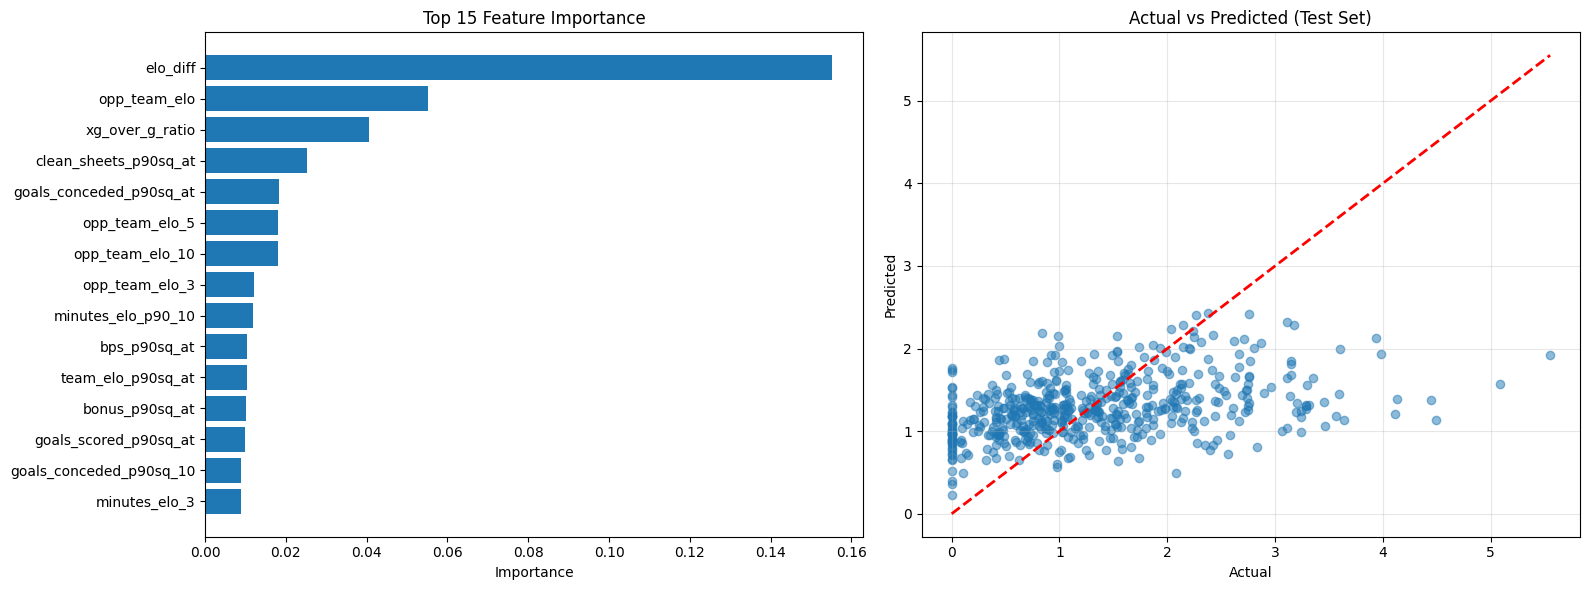

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 11997/18609

Training Set Performance:
R² Score: 0.5407
RMSE: 0.6348
MAE: 0.5044

Test Set Performance:
R² Score: 0.3404
RMSE: 0.7822
MAE: 0.6033

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.240787
         opp_team_elo    0.088471
       opp_team_elo_5    0.034142
      opp_team_elo_10    0.033893
             team_elo    0.030643
           team_elo_5    0.027585
       opp_team_elo_3    0.026641
          team_elo_10    0.020729
           team_elo_3    0.019078
       team_elo_elo_3    0.018682
   opp_team_elo_elo_5    0.016067
   opp_team_elo_elo_3    0.015836
       team_elo_elo_5    0.015710
  minutes_elo_p90sq_3    0.013956
clean_sheets_p90sq_at    0.013491
    minutes_elo_p90_3    0.013384
opp_team_elo_p90sq_at    0.011886
  opp_team_elo_elo_10    0.010269
      team_elo_elo_10    0.009972
 minutes_elo_p90sq_10    0.008842


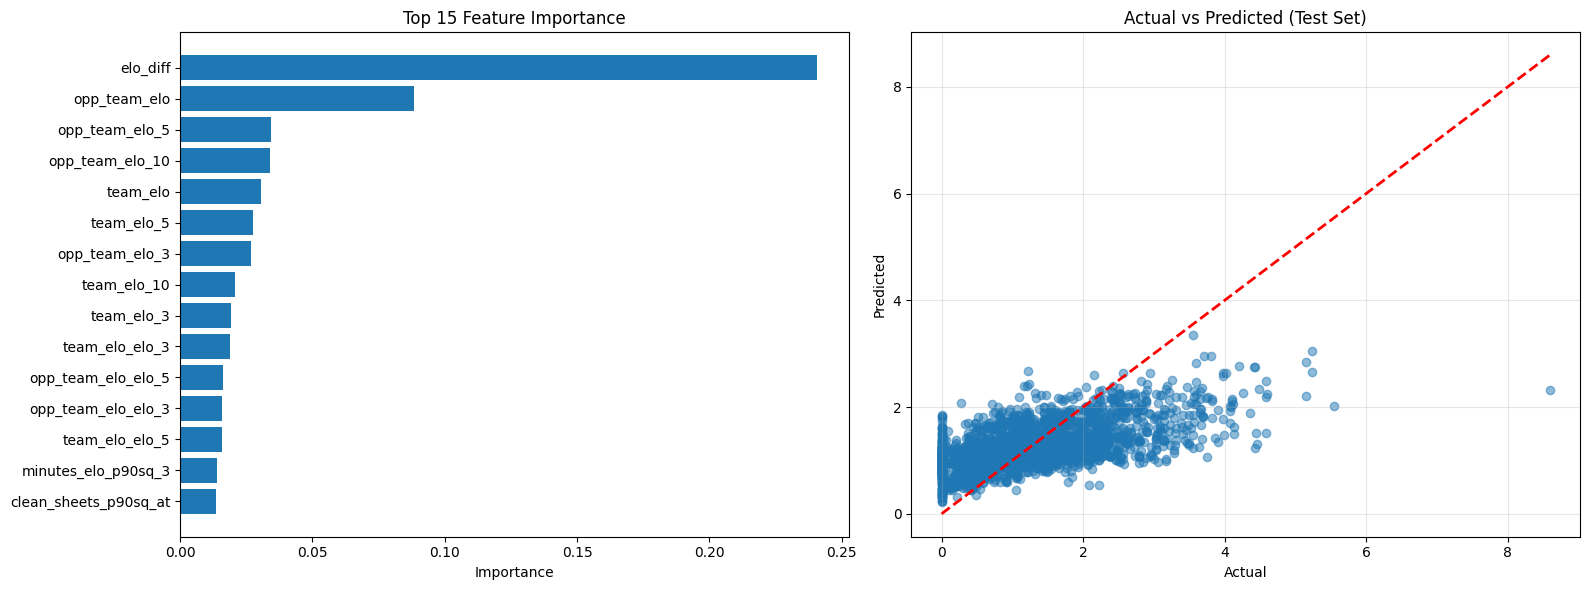

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10096/16407

Training Set Performance:
R² Score: 0.5940
RMSE: 0.6039
MAE: 0.4809

Test Set Performance:
R² Score: 0.3309
RMSE: 0.7517
MAE: 0.5865

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.203544
           opp_team_elo    0.080604
        opp_team_elo_10    0.030554
         opp_team_elo_5    0.029299
             team_elo_5    0.025920
    opp_team_elo_elo_10    0.025434
            team_elo_10    0.023732
               team_elo    0.023253
         opp_team_elo_3    0.021089
             team_elo_3    0.018368
         team_elo_elo_3    0.017912
     opp_team_elo_elo_3    0.015937
         team_elo_elo_5    0.015234
goals_conceded_p90sq_at    0.014773
  clean_sheets_p90sq_at    0.014198
     opp_team_elo_elo_5    0.013906
      minutes_elo_p90_3    0.011866
        team_elo_elo_10    0.011702
    minutes_elo_p90sq_3    0.011063
  opp_team_elo_p90sq_at    0.009

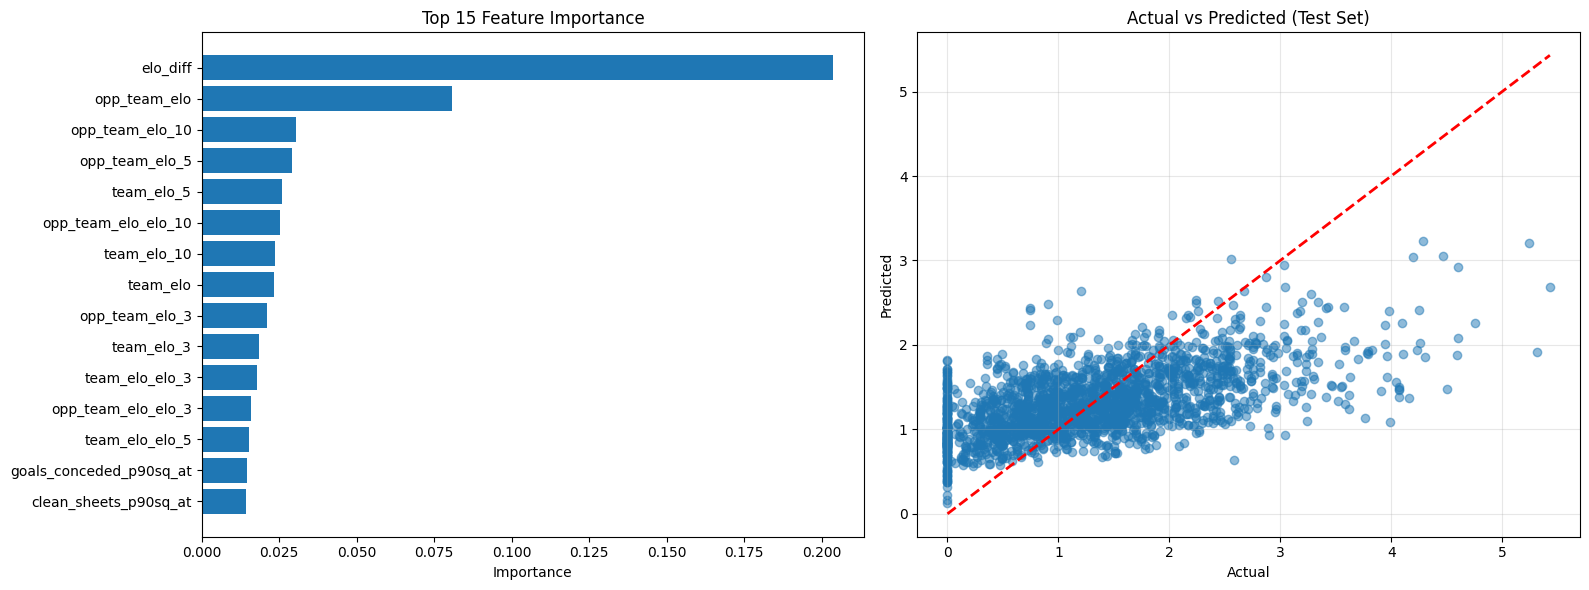

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2477/4011

Training Set Performance:
R² Score: 0.7061
RMSE: 0.5004
MAE: 0.4038

Test Set Performance:
R² Score: 0.1749
RMSE: 0.8495
MAE: 0.6669

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.157420
               opp_team_elo    0.042421
             saves_p90sq_at    0.034709
      opp_team_elo_p90sq_at    0.024674
    goals_conceded_p90sq_at    0.022347
          team_elo_p90sq_at    0.019921
      opp_team_elo_p90sq_10    0.019679
               bps_p90sq_at    0.019048
            opp_team_elo_10    0.016315
      total_points_p90sq_at    0.015110
      clean_sheets_p90sq_at    0.014112
             opp_team_elo_5    0.013508
         saves_elo_p90sq_10    0.012577
       opp_team_elo_p90sq_5    0.012319
             saves_p90sq_10    0.012252
          saves_elo_p90sq_5    0.011992
          saves_elo_p90sq_3    0.011818
               bps_p90sq_10    0.01

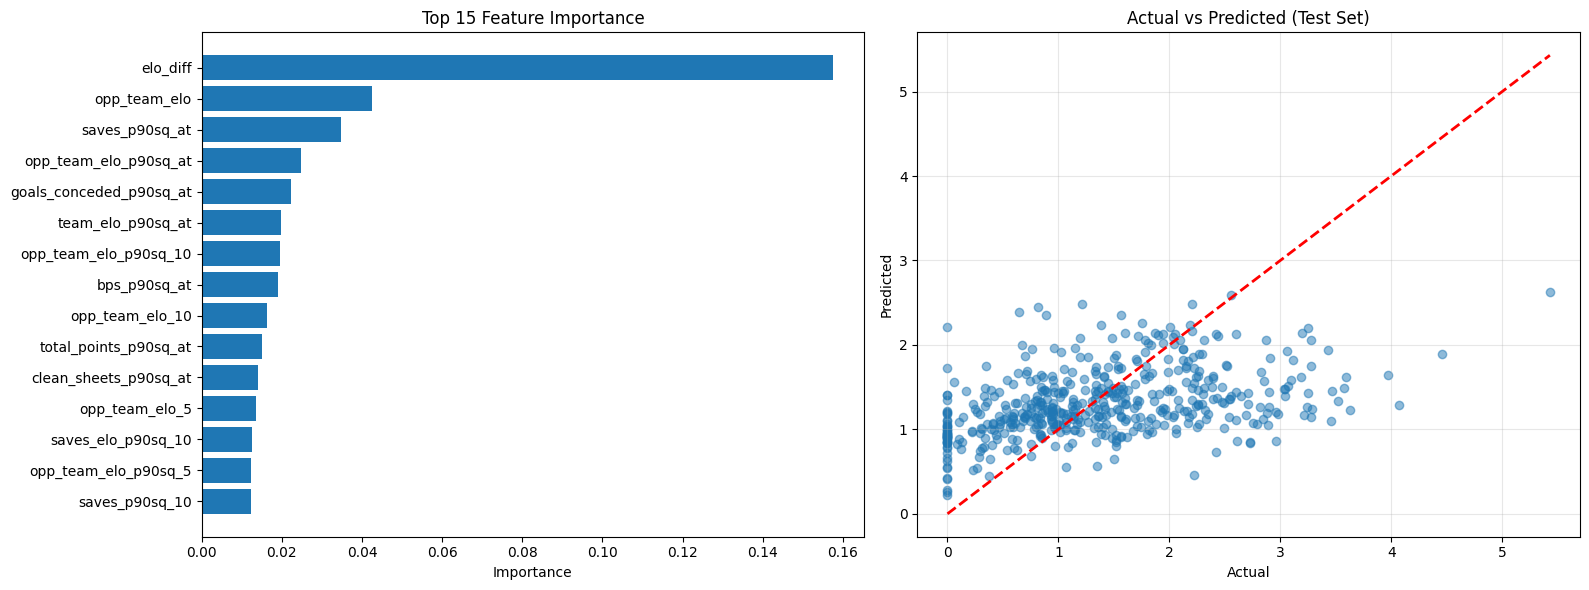

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 3977/4483

Training Set Performance:
R² Score: 0.5049
RMSE: 13.1765
MAE: 10.7334

Test Set Performance:
R² Score: -0.0476
RMSE: 18.2637
MAE: 14.4380

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.073768
             opp_team_elo    0.024369
          opp_team_elo_10    0.022500
           opp_team_elo_3    0.017526
           opp_team_elo_5    0.016367
           bonus_p90sq_at    0.015987
  goals_conceded_p90sq_at    0.014862
    opp_team_elo_p90sq_at    0.012908
clean_sheets_elo_p90sq_10    0.012504
             bps_p90sq_at    0.012000
       opp_team_elo_elo_5    0.011363
    total_points_p90sq_at    0.011089
        minutes_elo_p90_3    0.010828
    goals_scored_p90sq_at    0.010765
                bps_elo_5    0.010531
    clean_sheets_p90sq_at    0.009964
      minutes_elo_p90sq_5    0.009493
        team_elo_p90sq_at    0.009270
       opp_team_elo_elo_3    0.009090
     minu

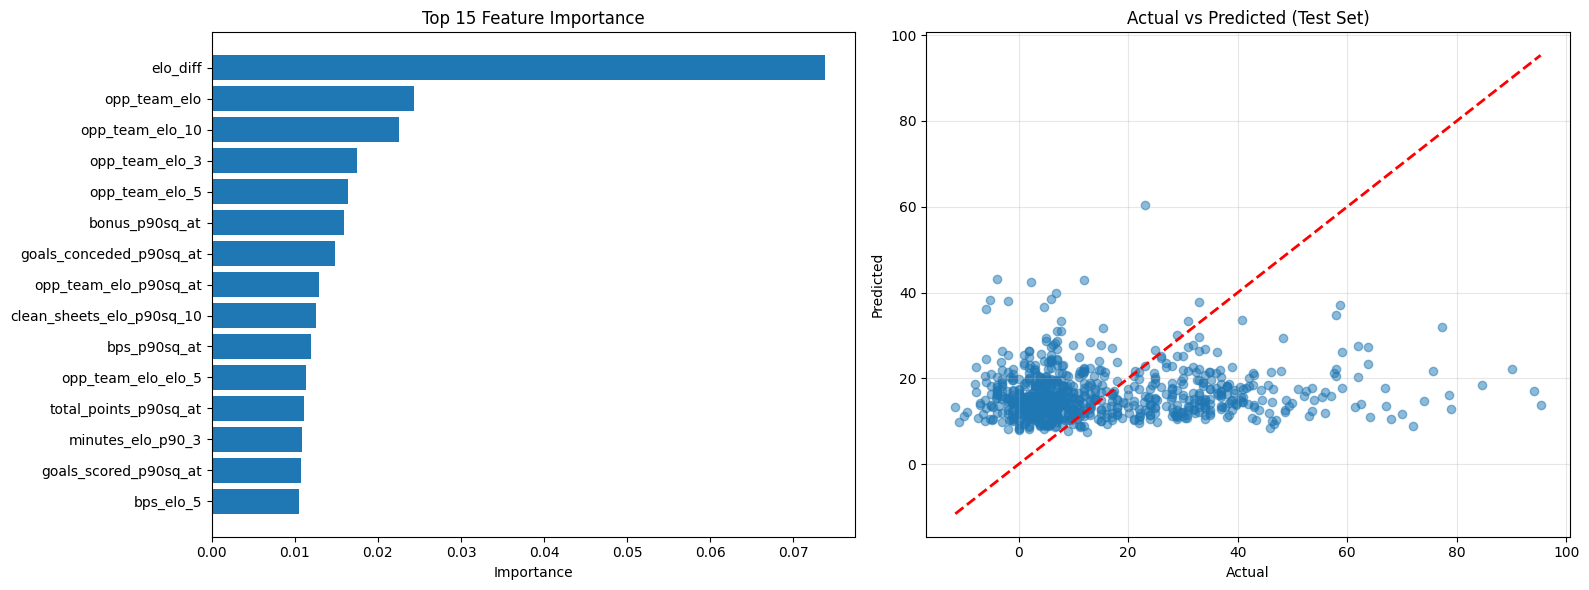

target=bps_per90, MID_bps_predictor
Cleaned df size: 18011/18609

Training Set Performance:
R² Score: 0.3092
RMSE: 9.5618
MAE: 7.2490

Test Set Performance:
R² Score: 0.0531
RMSE: 10.9491
MAE: 7.9618

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.137894
             bps_elo_10    0.033636
           opp_team_elo    0.023427
         bonus_p90sq_at    0.022182
                 bps_10    0.021980
                  bps_5    0.017896
        opp_team_elo_10    0.017843
         opp_team_elo_5    0.014318
           bps_p90sq_at    0.013781
  goals_scored_p90sq_at    0.013291
         opp_team_elo_3    0.012469
      team_elo_p90sq_at    0.011259
goals_conceded_p90sq_at    0.010657
    total_points_elo_10    0.010306
             bps_p90_10    0.009736
              bps_elo_5    0.009665
  clean_sheets_p90sq_at    0.009621
goals_conceded_p90sq_10    0.008611
              bps_elo_3    0.008340
  opp_team_elo_p90sq_at    0.008326


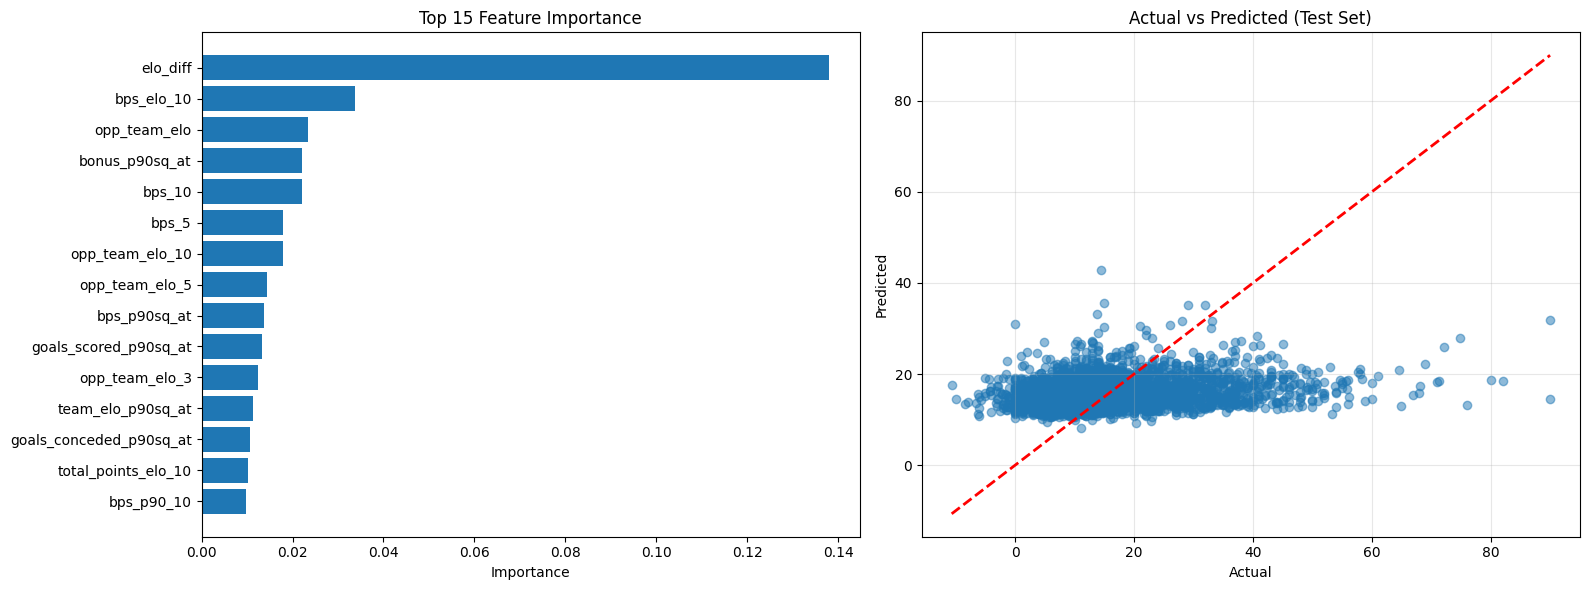

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15423/16407

Training Set Performance:
R² Score: 0.4318
RMSE: 7.4439
MAE: 5.9606

Test Set Performance:
R² Score: 0.1365
RMSE: 9.0156
MAE: 6.9874

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.224432
           opp_team_elo    0.032048
         opp_team_elo_5    0.024229
        opp_team_elo_10    0.024078
         opp_team_elo_3    0.016690
         bonus_p90sq_at    0.014726
goals_conceded_p90sq_at    0.013065
            bps_p90sq_5    0.012491
  clean_sheets_p90sq_at    0.012219
             bps_p90_10    0.010763
               team_elo    0.010339
        bps_elo_p90sq_3    0.010247
            team_elo_10    0.010213
        bps_elo_p90sq_5    0.009784
           bps_p90sq_at    0.009614
           bps_p90sq_10    0.009610
    minutes_elo_p90sq_3    0.009574
             team_elo_5    0.009480
             bps_elo_10    0.008845
            bps_p90sq_3    0.008799


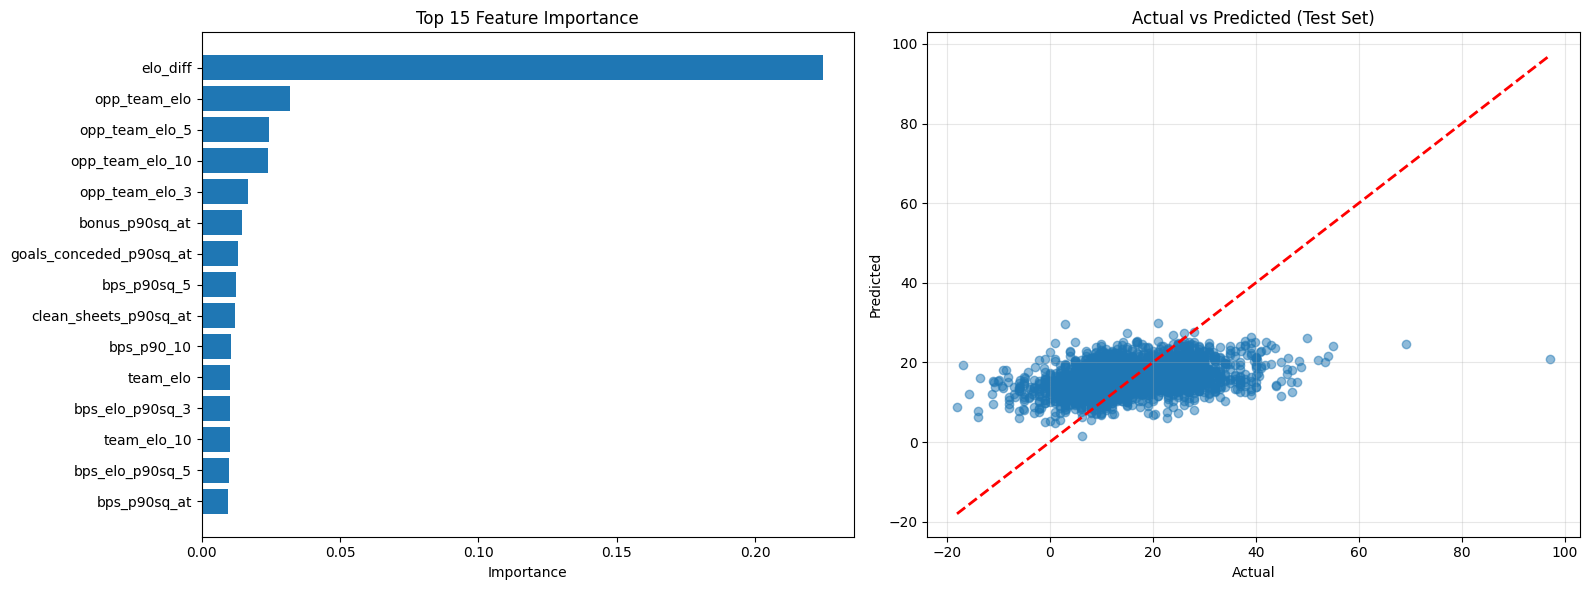

target=bps_per90, GK_bps_predictor
Cleaned df size: 3775/4011

Training Set Performance:
R² Score: 0.5438
RMSE: 5.9559
MAE: 4.8383

Test Set Performance:
R² Score: 0.0310
RMSE: 8.7269
MAE: 6.9818

Top 20 Feature Importances:
                feature  importance
           bps_p90sq_10    0.032369
           opp_team_elo    0.032015
        opp_team_elo_10    0.030651
       bps_elo_p90sq_10    0.028030
           bps_p90sq_at    0.024346
  opp_team_elo_p90sq_at    0.022867
      saves_elo_p90sq_3    0.019098
            bps_p90sq_3    0.017488
  total_points_p90sq_10    0.016718
             bps_p90_10    0.016652
goals_conceded_p90sq_at    0.016071
         saves_p90sq_10    0.015862
            bps_p90sq_5    0.015807
  opp_team_elo_p90sq_10    0.014808
         saves_p90sq_at    0.014721
   opp_team_elo_p90sq_3    0.014429
      team_elo_p90sq_at    0.013929
         opp_team_elo_3    0.013795
  total_points_p90sq_at    0.013550
          saves_p90sq_5    0.013531


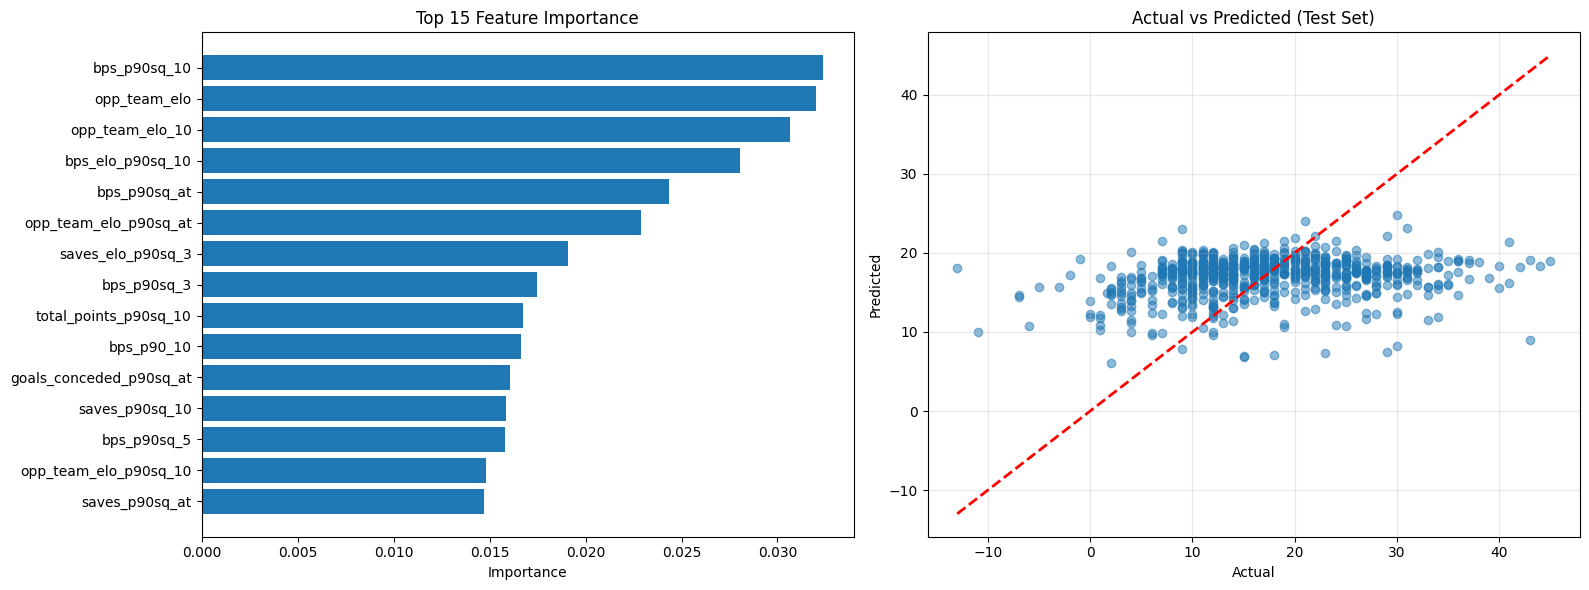

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3775/4030

Training Set Performance:
R² Score: 0.5928
RMSE: 1.2469
MAE: 1.0053

Test Set Performance:
R² Score: 0.0916
RMSE: 1.9032
MAE: 1.5062

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.130173
             saves_p90sq_at    0.021958
               opp_team_elo    0.021706
      opp_team_elo_p90sq_at    0.021309
            opp_team_elo_10    0.017515
             opp_team_elo_5    0.014906
    goals_conceded_p90sq_at    0.014594
      total_points_p90sq_at    0.014442
          team_elo_p90sq_at    0.014171
         saves_elo_p90sq_10    0.014050
             opp_team_elo_3    0.013982
      opp_team_elo_p90sq_10    0.013834
               bps_p90sq_at    0.012936
             bonus_p90sq_at    0.012889
             saves_p90sq_10    0.012614
       opp_team_elo_p90sq_5    0.010965
goals_conceded_elo_p90sq_10    0.010919
                bps_p90sq_5    0.010483
           

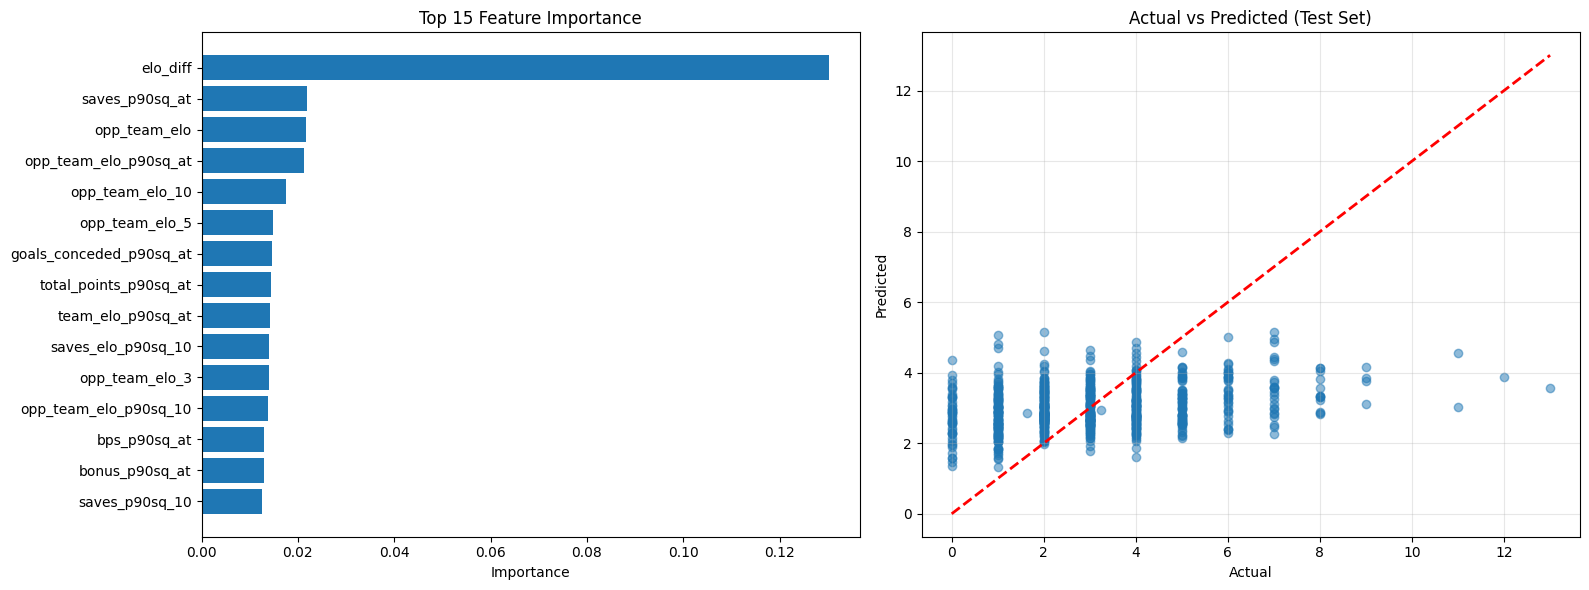

In [16]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 462/4956

Training Set Performance:
R² Score: 0.8168
RMSE: 1.1800
MAE: 0.9467

Test Set Performance:
R² Score: 0.1138
RMSE: 2.8452
MAE: 2.0832

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.038172
     total_points_p90sq_3    0.034993
           opp_team_elo_5    0.030041
           bonus_p90sq_at    0.019872
    opp_team_elo_p90sq_at    0.019278
        team_elo_p90sq_10    0.018752
    goals_conceded_p90_10    0.018318
    clean_sheets_p90sq_at    0.017565
          opp_team_elo_10    0.017306
       minutes_elo_p90_10    0.017244
             bps_p90sq_at    0.017105
                 team_elo    0.015951
             opp_team_elo    0.015439
  goals_conceded_p90sq_at    0.015166
               minutes_10    0.015045
     goals_conceded_elo_3    0.014064
    goals_conceded_elo_10    0.014015
           opp_team_elo_3    0.012847
opp_team_elo_elo_p90sq_10    0.

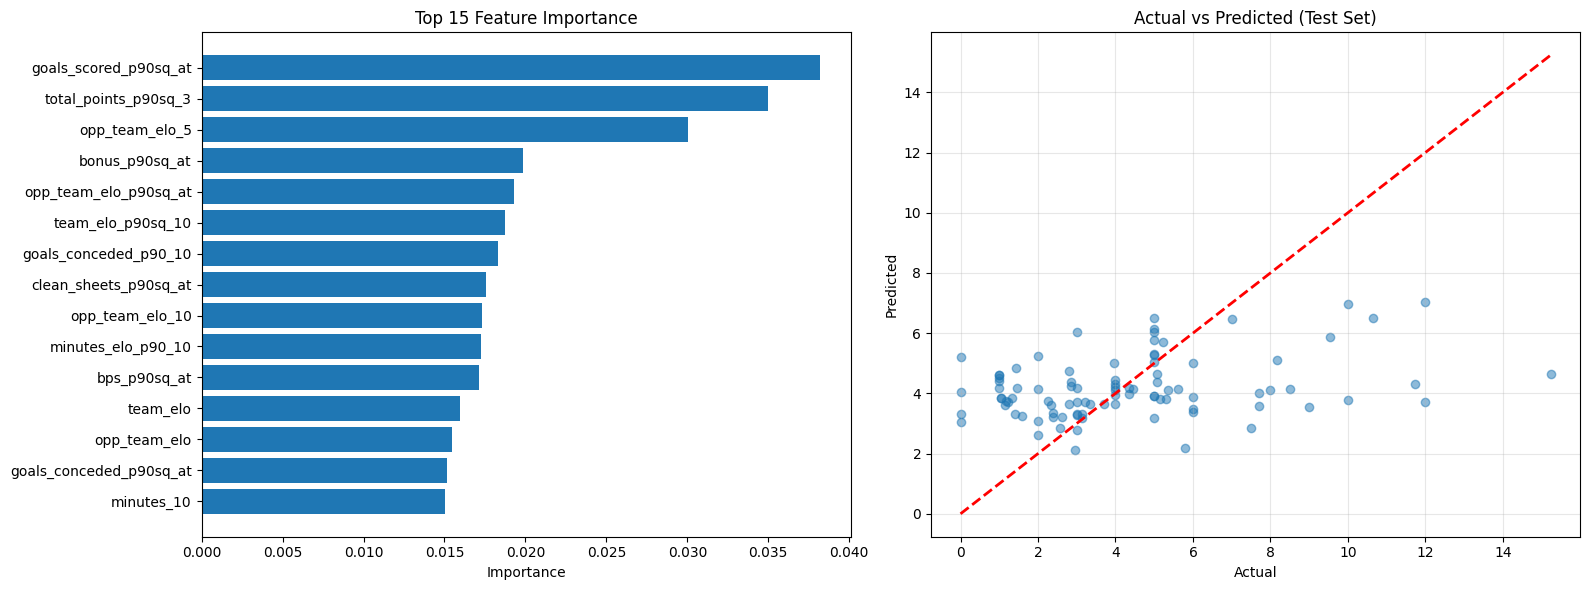

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2212/20455

Training Set Performance:
R² Score: 0.7188
RMSE: 2.1841
MAE: 1.7604

Test Set Performance:
R² Score: 0.1527
RMSE: 4.1222
MAE: 3.2098

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.095346
goals_conceded_p90sq_at    0.036385
               team_elo    0.020857
      team_elo_p90sq_at    0.020756
         bonus_p90sq_at    0.020273
  total_points_p90sq_at    0.018600
                  bps_3    0.017532
  opp_team_elo_p90sq_at    0.013918
           opp_team_elo    0.013336
           bps_p90sq_at    0.013018
    team_elo_elo_p90_10    0.012218
  clean_sheets_p90sq_at    0.012179
         opp_team_elo_3    0.012034
          minutes_elo_5    0.011316
                 bps_10    0.011190
         opp_team_elo_5    0.011063
    total_points_elo_10    0.010893
               elo_diff    0.010886
         bps_elo_p90_10    0.010458
              bps_p90_3    0.00

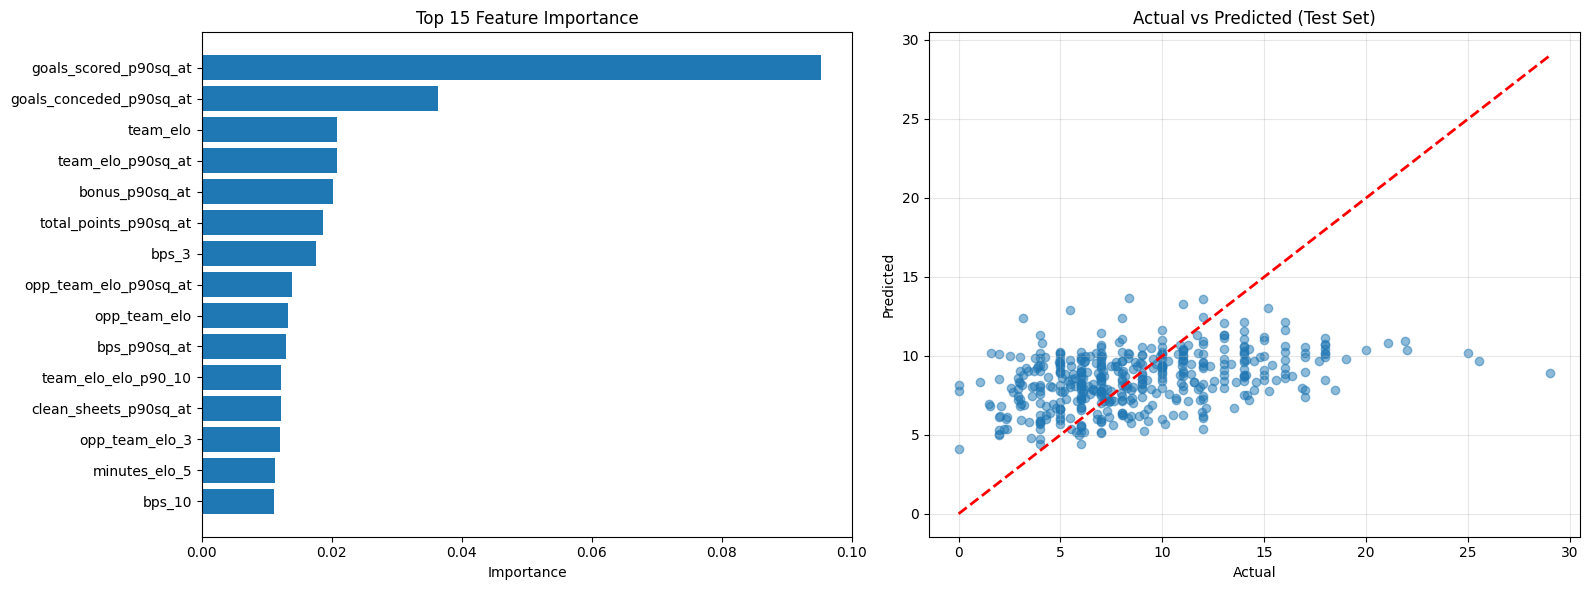

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1849/17333

Training Set Performance:
R² Score: 0.6785
RMSE: 2.1974
MAE: 1.7875

Test Set Performance:
R² Score: 0.1072
RMSE: 3.8519
MAE: 2.9217

Top 20 Feature Importances:
                    feature  importance
             opp_team_elo_3    0.022586
               opp_team_elo    0.021517
           team_elo_p90sq_5    0.021035
      opp_team_elo_p90sq_at    0.021006
       opp_team_elo_p90sq_5    0.020038
                   elo_diff    0.019115
             bonus_p90sq_at    0.018789
    opp_team_elo_elo_p90_10    0.017371
       opp_team_elo_p90sq_3    0.017171
    goals_conceded_p90sq_at    0.017013
      total_points_p90sq_at    0.016995
          team_elo_p90sq_at    0.015788
             opp_team_elo_5    0.015596
      goals_conceded_elo_10    0.015071
            opp_team_elo_10    0.013862
      total_points_p90sq_10    0.012403
goals_conceded_elo_p90sq_10    0.011918
       goals_conceded_elo_3    

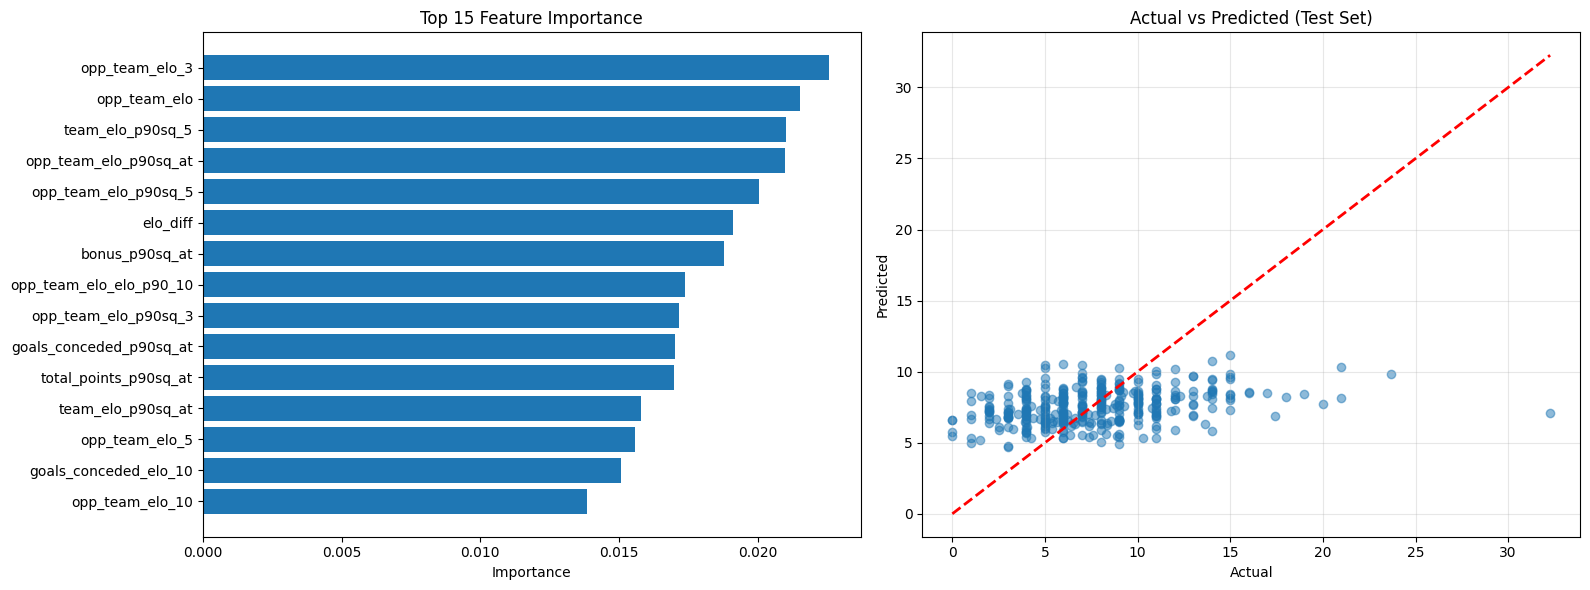

In [17]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

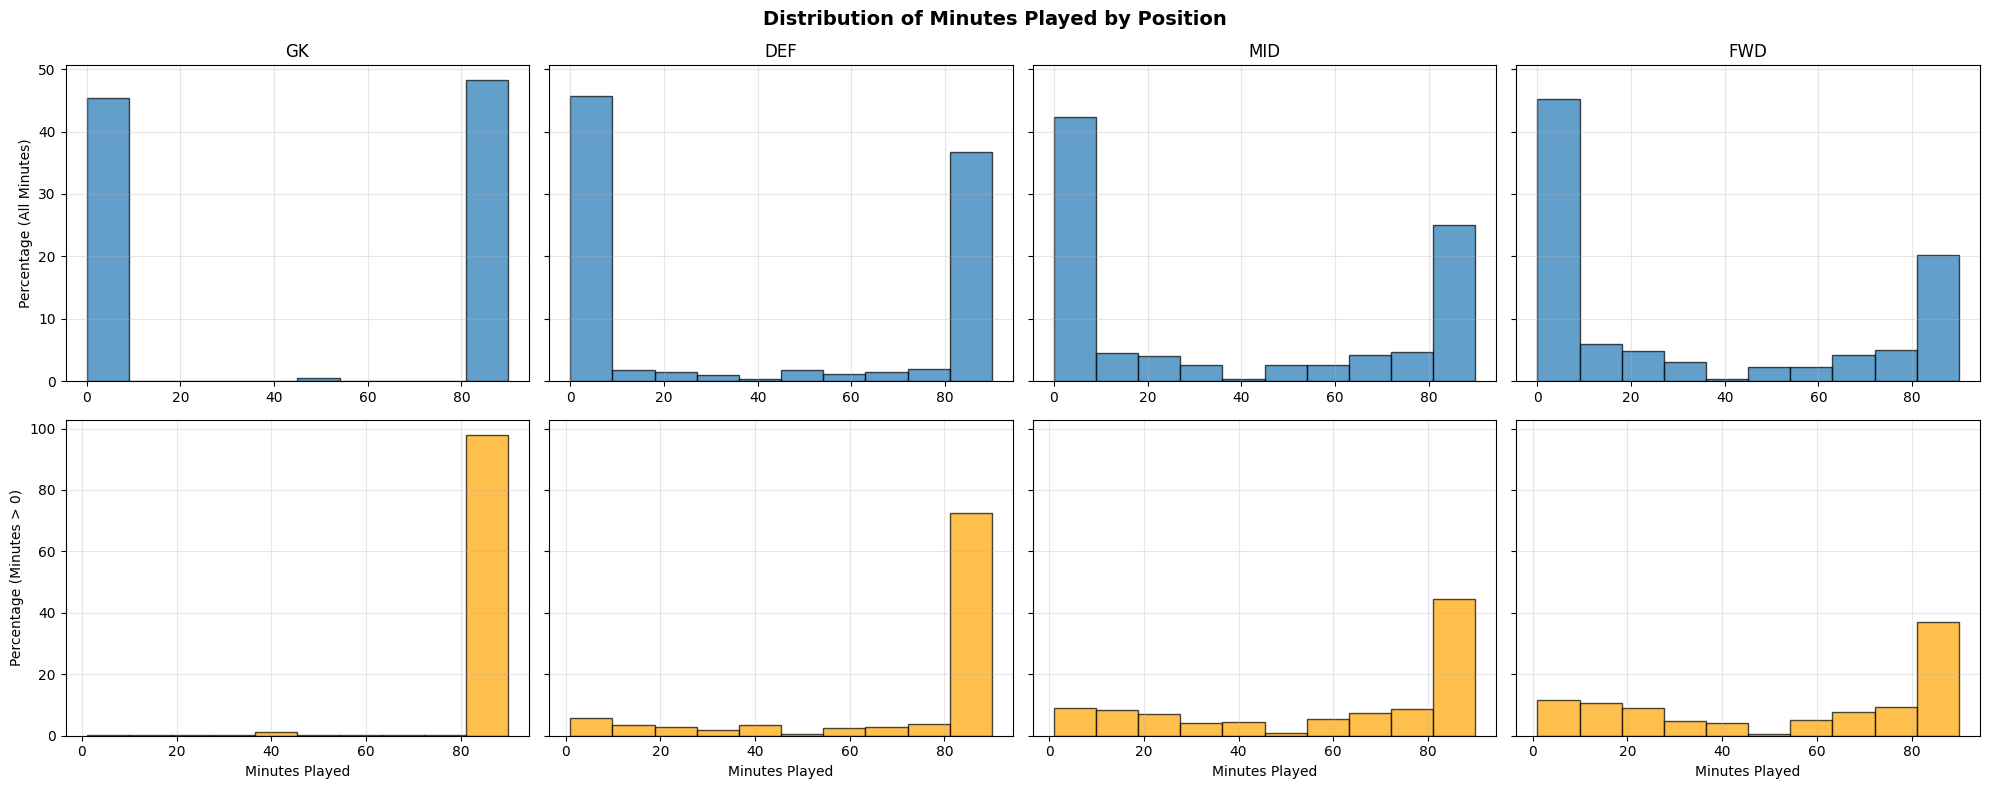

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.350


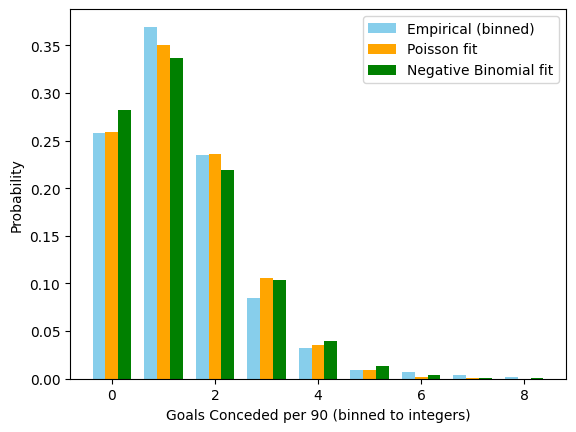

Mean: 1.342, Variance: 1.509
Overdispersion ratio (Var/Mean): 1.125
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.259


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.238


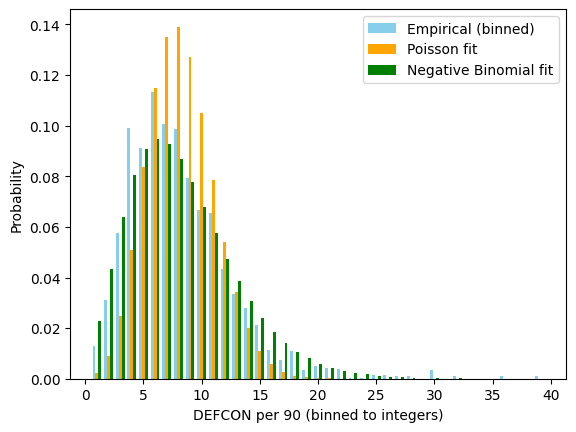

Mean: 8.231, Variance: 21.251
Overdispersion ratio (Var/Mean): 2.582
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [20]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.206


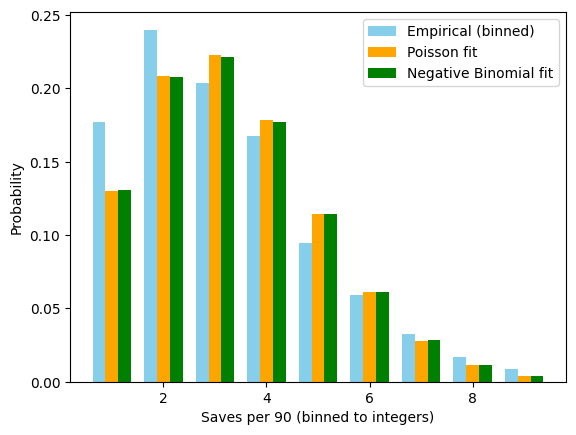

Mean: 3.206, Variance: 3.241
Overdispersion ratio (Var/Mean): 1.011
✅ Poisson assumption looks reasonable.


In [21]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [22]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [23]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [24]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    7395.000000
mean       59.334309
std        20.036798
min        15.344376
25%        40.797516
50%        60.881034
75%        77.759039
max        89.956777
Name: mins_pred, dtype: float64

In [25]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    6945.000000
mean        0.155107
std         0.130017
min         0.029051
25%         0.054785
50%         0.116377
75%         0.211502
max         0.755257
Name: xgp90_pred, dtype: float64

In [26]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    6945.000000
mean        0.099582
std         0.065009
min         0.026218
25%         0.049010
50%         0.077446
75%         0.135110
max         0.352392
Name: xap90_pred, dtype: float64

In [27]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    7395.000000
mean        1.445479
std         0.339878
min         0.407502
25%         1.210145
50%         1.431118
75%         1.679077
max         2.654333
Name: xgcp90_pred, dtype: float64

In [28]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    7395.000000
mean       15.780040
std         3.549154
min         3.667454
25%        13.513739
50%        15.374137
75%        17.648948
max        40.517143
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.382e+04
Date:                Sun, 25 Jan 2026   Prob (F-statistic):                        0.00
Time:                        11:24:14   Log-Likelihood:                         -39343.
No. Observations:               41738   AIC:                                  7.869e+04
Df Residuals:                   41737   BIC:                                  7.870e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

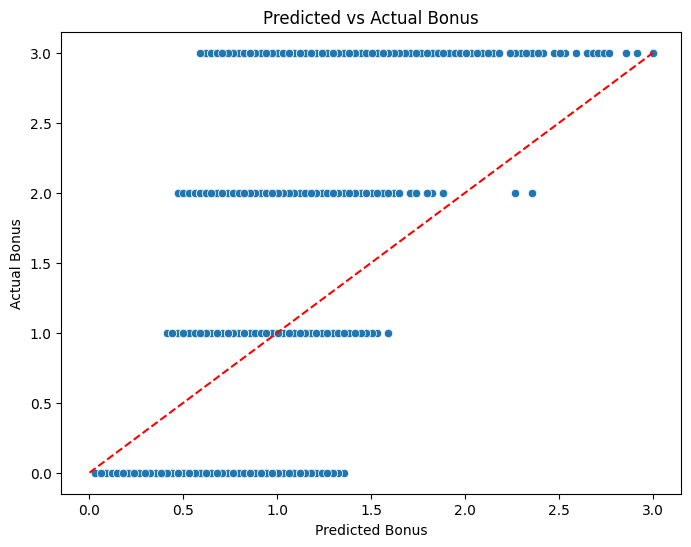

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459267  0.230344  1.106860  1.947781
FWD           0.332747  0.197970  1.047815  1.708243
GK            0.490060  0.245149  1.115122  2.012783
GKP                NaN       NaN       NaN       NaN
MID           0.395973  0.245834  1.049861  1.823956


C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [29]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [30]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [31]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    450.000000
mean       3.002843
std        0.617495
min        1.302844
25%        2.573051
50%        2.979628
75%        3.417207
max        4.774912
Name: xsavesp90_pred, dtype: float64

In [32]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    6945.000000
mean        7.740458
std         1.882813
min         2.675576
25%         6.719152
50%         7.918348
75%         9.133173
max        13.387377
Name: xdefconp90_pred, dtype: float64

In [33]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129276,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,24.0,Wolves,915.716268,41.576169,0.192772,0.247172,1.367130
129279,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,25.0,Aston Villa,1169.188712,39.772322,0.096947,0.168882,2.081012
129922,Adama Traoré Diarra,326.0,51.0,Fulham,MID,20252026.0,31.0,Burnley,889.643897,27.442781,0.136439,0.142752,1.245370
129924,Adama Traoré Diarra,326.0,51.0,Fulham,MID,20252026.0,32.0,Liverpool,1169.484614,28.708839,0.081172,0.105751,1.676154
129932,Adama Traoré Diarra,326.0,51.0,Fulham,MID,20252026.0,33.0,Brentford,1068.795600,28.336855,0.082112,0.081646,1.725831


In [34]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
147767,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,24.0,Liverpool,1169.484614,38.231619,0.677176,0.286436,1.529905
130224,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,24.0,Newcastle,1102.715042,38.126832,0.669743,0.291466,1.432273
145394,Rodrigo Muniz Carvalho,338.0,53.0,Fulham,FWD,20252026.0,24.0,Man Utd,1068.002544,32.689692,0.659757,0.288988,1.397061
143592,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,24.0,Nott'm Forest,1020.090100,29.359676,0.631880,0.323158,1.580535
131415,Benjamin Sesko,681.0,72.0,Man Utd,FWD,20252026.0,24.0,Fulham,1062.457219,60.505840,0.621791,0.115855,1.507518
139391,Kai Havertz,30.0,73.0,Arsenal,FWD,20252026.0,24.0,Leeds,972.748704,37.917767,0.613224,0.262438,1.280318
132520,Charalampos Kostoulas,181.0,48.0,Brighton,FWD,20252026.0,24.0,Everton,1063.956178,24.103583,0.601722,0.065805,1.399651
140785,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,24.0,West Ham,971.988000,41.598103,0.569933,0.250734,1.492133
134649,Erling Haaland,430.0,151.0,Man City,FWD,20252026.0,24.0,Spurs,990.668127,61.490546,0.538576,0.057360,0.616881
132465,Chris Wood,525.0,72.0,Nott'm Forest,FWD,20252026.0,24.0,Crystal Palace,1056.251684,33.409765,0.513394,0.324932,1.429702


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_24296\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [39]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395 entries, 0 to 7394
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          7395 non-null   object 
 1   team_name               7395 non-null   object 
 2   team_elo                7395 non-null   float64
 3   element                 7395 non-null   float64
 4   position                7395 non-null   object 
 5   opp_team_name           7395 non-null   object 
 6   opp_team_elo            7395 non-null   float64
 7   season                  7395 non-null   float64
 8   value                   7395 non-null   float64
 9   event                   7395 non-null   float64
 10  mins_pred               7395 non-null   float64
 11  xgp90_pred              6945 non-null   float64
 12  xap90_pred              6945 non-null   float64
 13  xgcp90_pred             7395 non-null   float64
 14  xpoints_mins            7395 non-null   

In [40]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [41]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [42]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 24 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
135551,Gabriel dos Santos Magalhães,5.0,24.0,69.0,Arsenal,DEF,Leeds,972.748704,72.652004,1.779920,0.499269,0.235642,2.272307,0.0,-0.113427,0.543410,0.654656,5.871777
147814,William Saliba,6.0,24.0,60.0,Arsenal,DEF,Leeds,972.748704,83.339878,1.911653,0.234038,0.146129,2.055365,0.0,-0.148929,0.543410,0.581082,5.322749
139336,Jurriën Timber,8.0,24.0,63.0,Arsenal,DEF,Leeds,972.748704,81.481190,1.895493,0.311504,0.142394,2.037263,0.0,-0.152194,0.543410,0.535733,5.313603
144918,Riccardo Calafiori,7.0,24.0,56.0,Arsenal,DEF,Leeds,972.748704,62.252760,1.556082,0.825876,0.104449,1.786885,0.0,-0.202800,0.543410,0.611393,5.225294
141766,Matheus Nunes,407.0,24.0,55.0,Man City,DEF,Spurs,990.668127,65.566723,1.635682,0.167562,0.195342,2.082752,0.0,-0.144081,0.543410,0.661489,5.142156
130797,Antoine Semenyo,82.0,24.0,77.0,Man City,MID,Spurs,990.668127,85.639345,1.928504,1.166076,0.609078,0.335679,0.0,0.000000,0.512244,0.539613,5.091194
131448,Benjamin White,11.0,24.0,51.0,Arsenal,DEF,Leeds,972.748704,68.592223,1.702498,0.282406,0.160700,1.915905,0.0,-0.175407,0.543410,0.630789,5.060300
143389,Nico O'Reilly,411.0,24.0,51.0,Man City,DEF,Spurs,990.668127,70.169402,1.734376,0.215761,0.126656,1.974581,0.0,-0.163890,0.543410,0.594439,5.025333
129857,Abdukodir Khusanov,406.0,24.0,54.0,Man City,DEF,Spurs,990.668127,76.709394,1.841701,0.198265,0.119982,1.889593,0.0,-0.180757,0.543410,0.579491,4.991684
139146,Joško Gvardiol,403.0,24.0,60.0,Man City,DEF,Spurs,990.668127,59.325489,1.483144,0.457725,0.135123,1.934975,0.0,-0.171602,0.543410,0.592391,4.975165


In [43]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW24 - GW28


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
152,Gabriel dos Santos Magalhães,363.260021,8.899600,2.478803,1.046977,8.914313,0.0,-1.090547,2.717051,2.855995,25.822192
27,Antoine Semenyo,428.902735,9.647160,5.667970,2.897946,1.514589,0.0,0.000000,2.561221,2.641924,24.930810
17,Amad Diallo,347.818748,8.611977,7.302948,2.708052,1.249809,0.0,0.000000,2.561221,2.317570,24.751576
345,Morgan Rogers,396.000214,9.360583,5.329597,2.484106,1.756147,0.0,0.000000,2.561221,2.869611,24.361265
402,Riccardo Calafiori,311.770350,7.792865,4.271441,0.518911,7.589008,0.0,-1.401588,2.717051,2.774652,24.262340
99,Declan Rice,399.929813,9.403155,3.924846,2.875006,2.063432,0.0,0.000000,2.561221,3.153080,23.980740
252,Jurriën Timber,408.175951,9.484454,1.555472,0.645454,8.347735,0.0,-1.204306,2.717051,2.267116,23.812975
477,William Saliba,416.699388,9.558265,1.122804,0.655761,8.347444,0.0,-1.212504,2.717051,2.602853,23.791675
59,Bruno Guimarães Rodriguez Moura,415.351143,9.547192,4.845955,2.733121,1.209593,0.0,0.000000,2.561221,2.659264,23.556344
167,Harry Wilson,428.883236,9.646989,4.977628,2.184838,1.291621,0.0,0.000000,2.561221,2.521694,23.183991


In [44]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
152,Gabriel dos Santos Magalhães,1089.313259,26.690655,7.397497,3.217266,26.086315,0.0,-3.431664,8.151153,8.339949,76.451170
27,Antoine Semenyo,1287.066687,28.943824,17.090632,8.603175,4.629006,0.0,0.000000,7.683662,7.929114,74.879415
17,Amad Diallo,1043.447799,25.835751,22.162736,7.822748,3.389199,0.0,0.000000,7.683662,6.904128,73.798224
345,Morgan Rogers,1188.199808,28.084034,15.791897,7.192260,4.987467,0.0,0.000000,7.683662,8.294966,72.034286
402,Riccardo Calafiori,935.155062,23.374468,12.773483,1.566262,22.146423,0.0,-4.451782,8.151153,8.256359,71.816366
99,Declan Rice,1199.288977,28.204284,11.645625,8.594929,6.112061,0.0,0.000000,7.683662,9.464276,71.704837
59,Bruno Guimarães Rodriguez Moura,1247.121106,28.650294,14.574188,8.856151,3.809277,0.0,0.000000,7.683662,8.126466,71.700037
252,Jurriën Timber,1224.546974,28.453541,4.671253,2.056328,24.360481,0.0,-3.831829,8.151153,6.710830,70.571759
167,Harry Wilson,1285.348092,28.931880,15.194745,6.867272,4.080323,0.0,0.000000,7.683662,7.759532,70.517414
477,William Saliba,1248.643533,28.662724,3.354089,1.968082,24.484617,0.0,-3.812090,8.151153,7.704575,70.513150


In [45]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': stats_current_gameweek
})

In [46]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [47]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [48]:
# Step 1: Insert new predictions that don't exist yet
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,  -- Add these explicitly
    fixture, total_points
)
SELECT p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
                       
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season
WHERE NOT EXISTS (
    SELECT 1 
    FROM predictions_allgws pa 
    WHERE pa.player_name_id = p.player_name_id 
        AND pa.event = p.event 
        AND pa.season = p.season
);
""")

In [49]:
# Step 2: Update existing predictions with actual results (where total_points is still NULL)
db_creator.execute_sql("""
UPDATE predictions_allgws pa
SET
    fixture = pg.fixture,
    total_points = pg.total_points
FROM playergw pg
WHERE pa.player_name_id = pg.player_name_id
  AND pa.event = pg.event
  AND pa.season = pg.season
  AND pg.total_points IS NOT NULL;  -- Only update rows without actual points yet
""")

print(f"Successfully added/updated gameweek {stats_current_gameweek} predictions in predictions_allgws")

Successfully added/updated gameweek 23 predictions in predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==stats_current_gameweek) & (
    view['event']==stats_current_gameweek+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
180349,Erling Haaland,13.0,20252026.0,2.0,90.0
180350,Erling Haaland,14.0,20252026.0,14.0,90.0
180351,Erling Haaland,15.0,20252026.0,2.0,68.0
180352,Erling Haaland,16.0,20252026.0,13.0,90.0
180353,Erling Haaland,17.0,20252026.0,16.0,90.0
180354,Erling Haaland,18.0,20252026.0,2.0,90.0
180355,Erling Haaland,19.0,20252026.0,2.0,90.0
180356,Erling Haaland,20.0,20252026.0,2.0,90.0
180357,Erling Haaland,21.0,20252026.0,6.0,90.0
180358,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
657,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
5428,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
5444,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
5429,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5430,Erling Haaland,2026-01-05 18:33:33.065519,25.0,4.491019,NaN
5431,Erling Haaland,2026-01-05 18:33:33.065519,26.0,5.711853,NaN
5432,Erling Haaland,2026-01-05 18:33:33.065519,27.0,5.560836,NaN
5433,Erling Haaland,2026-01-05 18:33:33.065519,28.0,6.834615,NaN
5434,Erling Haaland,2026-01-05 18:33:33.065519,29.0,6.122355,NaN
5435,Erling Haaland,2026-01-05 18:33:33.065519,30.0,6.792673,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=stats_current_gameweek)&(
                df_preds['event']<=stats_current_gameweek+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

total_points  \
prediction_timestamp       prediction_gameweek season     event                 
2026-01-05 18:33:33.065519 20                  20252026.0 23.0       0.857732   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-07 16:29:20.849190 21                  20252026.0 23.0       3.000000   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-08 16:44:49.940956 21                  20252026.0 23.0       0.000000   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-22 16:59:38.976316 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-23 11:49:44.805713 22                  20252026.0 23.0       2.000000   
2026-01-25 11:24:25.347489 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   

                                                                  xpoints  
prediction_timestamp       prediction_gameweek season     event            
2026-01-05 18:33:33.065519 20                  20252026.0 23.0   3.414770  
                                                          24.0   3.426012  
                                                          25.0   3.409847  
                                                          26.0   3.426947  
                                                          27.0   3.437517  
                                                          28.0   3.421395  
2026-01-07 16:29:20.849190 21                  20252026.0 23.0   3.041140  
                                                          24.0   2.931663  
                                                          25.0   3.408648  
                                                          26.0   3.039378  
                                                          27.0   3.133860  
                                                          28.0   2.917792  
2026-01-08 16:44:49.940956 21                  20252026.0 23.0   4.013784  
                                                          24.0   4.314446  
                                                          25.0   3.456770  
                                                          26.0   4.041483  
                                                          27.0   3.590957  
                                                          28.0   3.890643  
2026-01-22 16:59:38.976316 23    

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,15
2026-01-23 11:49:44.805713,3
2026-01-25 11:24:25.347489,5


In [55]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,25.500000
min,2026-01-07 16:29:20.849190,23.000000
25%,2026-01-07 16:29:20.849189888,24.000000
50%,2026-01-08 04:37:05.395073024,25.500000
75%,2026-01-08 16:44:49.940955904,27.000000
max,2026-01-08 16:44:49.940956,28.000000
std,NaN,1.744557


In [56]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [57]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 31.91 minute(s)


In [58]:
view = db_creator.table_to_df('playergw')
cols =  ['player_name_id',
#  'element',
#  'value',
 'season',
 'event',
#  'fixture',
#  'total_points',
#  'minutes',
#  'goals_scored',
#  'assists',
#  'team_elo',
#  'opp_team_elo',
 'position',
#  'bonus',
#  'bps',
#  'clean_sheets',
#  'goals_conceded',
#  'was_home',
#  'expected_assists',
#  'expected_goal_involvements',
#  'expected_goals',
#  'expected_goals_conceded',
#  'starts',
#  'cbi',
#  'defensive_contribution',
#  'recoveries',
#  'tackles',
#  'saves',
 'team_name',
#  'opp_team_name'
 ]
filtered = (view['season']==20252026) & (view['position']=='MID')
players = view[cols][filtered].sort_values(['event'],ascending=True).groupby('player_name_id').agg({
    'team_name':'last'})
players.reset_index().to_csv('2526players_mids.csv', index=False)
players.info()

<class 'pandas.core.frame.DataFrame'>
Index: 361 entries, Aaron Ramsey to İlkay Gündoğan
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   team_name  361 non-null    object
dtypes: object(1)
memory usage: 5.6+ KB
